# CIS 5270 — Trustworthy ML: Linear Systems Fine-Tuning Notebook

**Team:** Margarita Granat · Marwan Achi · Rafiz Sadique

---

This notebook has two parts:

| Part | Sections | Purpose |
|------|----------|---------|
| **Data Generation Pipeline** | 0.1 – 0.7 | Generate synthetic systems, write `training.jsonl` / `validation.jsonl` / `eval.jsonl`, spot-check distributions, define grading functions |
| **Azure Fine-Tuning Workflow** | 1 – 8 | Upload data, launch SFT / DPO / RFT jobs, monitor, deploy, test, tear down |

**Run all of Section 0 before Section 3.** Section 3 reads the JSONL files
written by Section 0.4.

# Section 0: Data Generation


## Section 0.1 — Imports & Global Configuration

All generation behaviour is controlled by the constants in the cell below.
Changing `COEFF_RANGE`, `X_STAR_RANGE`, or `N_VARS_MIN/MAX` propagates
automatically to every generator, formatter, and grader.

In [33]:
import numpy as np
import random
import json
import re
import os
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── Reproducibility ──────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# ── Variable pool (always alphabetical — drives output format) ────────────────
VARIABLES = ['x', 'y', 'z', 'w', 'u', 'v']

# ── System size ──────────────────────────────────────────────────────────────────────────
N_VARS_MIN = 2
N_VARS_MAX = 3

# ── Coefficient ranges  (np.random.randint convention: [low, high)) ───────────────
COEFF_RANGE  = (-6, 7)    # A-matrix integer entries:        -6 … +6
X_STAR_RANGE = (-5, 6)    # Ground-truth solution entries:   -5 … +5
LC_RANGE     = (-3, 4)    # Linear-combination weights:      -3 … +3

# ── Dataset sizes ───────────────────────────────────────────────────────────────────────
N_TRAIN_TOTAL = 10000
N_VAL_TOTAL   =  1000
N_EVAL_TOTAL  =  1000

TYPE_WEIGHTS   = {'unique': 2.0, 'no_solution': 0.5, 'infinite': 0.5}
N_VARS_WEIGHTS = {2: 1.0, 3: 2.0}

# ── LLM inference tunables ────────────────────────────────────────────────────────────
MAX_TOKENS           = 200   # max tokens for direct-answer responses
REASONING_MAX_TOKENS = 512   # max tokens for reasoning-trace responses
TEMPERATURE          = 0.0
REQUEST_TIMEOUT      = 20

# ── Output paths ──────────────────────────────────────────────────────────────────────────────
TRAIN_JSONL = 'training.jsonl'
VAL_JSONL   = 'validation.jsonl'
EVAL_JSONL  = 'eval.jsonl'

# ── Reasoning-trace toggle ────────────────────────────────────────────────────────────
# Set to True to include step-by-step Gauss–Jordan traces in every assistant
# turn and 'answer' field.  All three datasets (train, val, eval) flip together.
# The parser and eval harness adjust automatically based on this flag.
INCLUDE_REASONING = False

# ── System prompts ───────────────────────────────────────────────────────────────────────
# SYSTEM_PROMPT is set automatically from the flag; do not edit it directly.

SYSTEM_PROMPT_DIRECT = (
    "You solve systems of linear equations with integer coefficients. "
    "Output EXACTLY ONE of the following three formats and nothing else. "
    "Do NOT explain your reasoning or add any other text.\n"
    "(1) Unique solution — list every variable assignment comma-separated "
    "in alphabetical order, e.g.: x=2, y=-1, z=0\n"
    "(2) No solution — output exactly: NO SOLUTION\n"
    "(3) Infinitely many solutions — output exactly: INFINITE"
)

SYSTEM_PROMPT_REASONING = (
    "You solve systems of linear equations with integer coefficients. "
    "Place your final answer on its own line starting with \"ANSWER:\" "
    "using EXACTLY ONE of the following three formats:\n"
    "(1) Unique solution — list every variable assignment comma-separated "
    "in alphabetical order: ANSWER: x=2, y=-1, z=0\n"
    "(2) No solution: ANSWER: NO SOLUTION\n"
    "(3) Infinitely many solutions: ANSWER: INFINITE"
)

SYSTEM_PROMPT = SYSTEM_PROMPT_REASONING if INCLUDE_REASONING else SYSTEM_PROMPT_DIRECT

# ── Numerical tolerances ──────────────────────────────────────────────────────────────────
_RANK_TOL     = 1e-9
_RESIDUAL_TOL = 1e-6

# ── Generator retry limits ───────────────────────────────────────────────────────────────
_MAX_ROW_RETRIES    = 300
_MAX_LC_RETRIES     = 100
_MAX_UNIQUE_RETRIES = 500
_MAX_NO_SOL_RETRIES = 300
_MAX_PERTURB_TRIES  = 100
_PERTURBATION_DELTAS = [-4, -3, -2, -1, 1, 2, 3, 4]

# ── Distribution spot-check ───────────────────────────────────────────────────────────────
N_SAMPLES = 2


print('Global configuration loaded.')
print(f'  n_vars range     : {N_VARS_MIN} – {N_VARS_MAX}')
print(f'  COEFF_RANGE      : {COEFF_RANGE}')
print(f'  X_STAR_RANGE     : {X_STAR_RANGE}')
print(f'  LC_RANGE         : {LC_RANGE}')
print(f'  Train/Val/Eval   : {N_TRAIN_TOTAL} / {N_VAL_TOTAL} / {N_EVAL_TOTAL}')
print(f'  TYPE_WEIGHTS     : {TYPE_WEIGHTS}')
print(f'  N_VARS_WEIGHTS   : {N_VARS_WEIGHTS}')
print(f'  Tolerances       : rank={_RANK_TOL}, residual={_RESIDUAL_TOL}')
print(f'  MAX_TOKENS       : {MAX_TOKENS} (direct) / {REASONING_MAX_TOKENS} (reasoning)')
print(f'  INCLUDE_REASONING: {INCLUDE_REASONING}')
print(f'  Active prompt    : {"SYSTEM_PROMPT_REASONING" if INCLUDE_REASONING else "SYSTEM_PROMPT_DIRECT"}')


Global configuration loaded.
  n_vars range     : 2 – 3
  COEFF_RANGE      : (-6, 7)
  X_STAR_RANGE     : (-5, 6)
  LC_RANGE         : (-3, 4)
  Train/Val/Eval   : 10000 / 1000 / 1000
  TYPE_WEIGHTS     : {'unique': 2.0, 'no_solution': 0.5, 'infinite': 0.5}
  N_VARS_WEIGHTS   : {2: 1.0, 3: 2.0}
  Tolerances       : rank=1e-09, residual=1e-06
  MAX_TOKENS       : 200 (direct) / 512 (reasoning)
  INCLUDE_REASONING: False
  Active prompt    : SYSTEM_PROMPT_DIRECT


## Section 0.2 — Core System Generators

Three generators produce the three solution-type classes.  They share a
private helper `_make_rank_deficient` that builds rank-deficient square
matrices.

### Key design notes

* **Square systems only** — `n` equations in `n` unknowns as specified.
* **Infinite solutions** — between 1 and `n−1` rows are random integer linear
  combinations of the remaining rows (each column of the matrix is independent).
  The number of dependent rows `n_dep` is sampled uniformly from
  `{1, …, n−1}`, giving genuine variety for large `n`.
* **No solution** — same rank-deficient construction as infinite, but `b` is
  then perturbed entry-wise until `rank([A|b]) > rank(A)`.
* **Verification** — `verify_solution_type(A, b)` re-derives the type from
  rank conditions and is used as a sanity-check assertion during generation.

In [34]:
def _make_rank_deficient(n_vars):
    """
    Build an n_vars × n_vars integer matrix with rank < n_vars.

    Between 1 and n_vars-1 rows are random integer linear combinations of
    the remaining n_independent = n_vars - n_dep base rows.

    Returns
    -------
    A     : np.ndarray[int], shape (n_vars, n_vars)
    n_dep : int  —  number of dependent rows inserted
    """
    n_dep = random.randint(1, n_vars - 1)
    n_ind = n_vars - n_dep

    # Draw n_ind genuinely linearly-independent rows
    for _ in range(_MAX_ROW_RETRIES):
        base = np.random.randint(*COEFF_RANGE, size=(n_ind, n_vars))
        if np.linalg.matrix_rank(base.astype(float), tol=_RANK_TOL) == n_ind:
            break
    else:
        raise RuntimeError(
            f'_make_rank_deficient: could not find {n_ind} independent rows '
            f'in {_MAX_ROW_RETRIES} attempts (n_vars={n_vars}, COEFF_RANGE={COEFF_RANGE})'
        )

    # Build each dependent row as a non-trivial LC of the base rows
    dep_rows = []
    for _ in range(n_dep):
        for _ in range(_MAX_LC_RETRIES):
            lc = np.random.randint(*LC_RANGE, size=n_ind)
            if np.any(lc != 0):
                dep_rows.append(lc @ base)
                break
        else:
            raise RuntimeError(
                f'_make_rank_deficient: LC_RANGE={LC_RANGE} produced only '
                f'all-zero coefficients after {_MAX_LC_RETRIES} attempts'
            )

    # Interleave independent and dependent rows randomly
    all_rows = list(base) + [np.asarray(r, dtype=int) for r in dep_rows]
    random.shuffle(all_rows)
    return np.array(all_rows, dtype=int), n_dep


# ─────────────────────────────────────────────────────────────────────────────

def generate_unique(n_vars):
    """
    Full-rank n_vars × n_vars system with a unique integer solution.

    Construction:
      1. Sample an invertible integer matrix A (rank == n_vars).
      2. Sample integer x*, then set b = A @ x*.

    Returns: A, b, x_star  (all np.ndarray, dtype int)
    """
    for _ in range(_MAX_UNIQUE_RETRIES):
        A = np.random.randint(*COEFF_RANGE, size=(n_vars, n_vars))
        if np.linalg.matrix_rank(A.astype(float), tol=_RANK_TOL) == n_vars:
            break
    else:
        raise RuntimeError(
            f'generate_unique: could not find invertible A in {_MAX_UNIQUE_RETRIES} attempts '
            f'(n_vars={n_vars}, COEFF_RANGE={COEFF_RANGE})'
        )
    x_star = np.random.randint(*X_STAR_RANGE, size=n_vars)
    b = A @ x_star
    return A, b, x_star


def generate_infinite(n_vars):
    """
    Rank-deficient n_vars × n_vars system with infinitely many solutions.

    Construction:
      1. Build rank-deficient A via _make_rank_deficient.
      2. Sample x*, compute b = A @ x*.
         => rank(A) = rank([A|b]) < n_vars  (consistent, underdetermined).

    Returns: A, b (np.ndarray, int), n_dep (int)
    """
    A, n_dep = _make_rank_deficient(n_vars)
    x_star   = np.random.randint(*X_STAR_RANGE, size=n_vars)
    b        = A @ x_star
    return A, b, n_dep


def generate_no_solution(n_vars):
    """
    Rank-deficient n_vars × n_vars system with no solution.

    Construction:
      1. Build rank-deficient A (identical structure to generate_infinite).
      2. Start from a consistent b = A @ x_ref.
      3. Perturb one row entry of b by a nonzero integer delta until
         rank([A|b]) > rank(A)  (inconsistent).

    Why single-entry perturbations work: for rank-deficient integer A,
    the column space col(A) is a proper subspace of Z^n.  A random
    integer delta*e_i is almost never in col(A), so a small number of
    (row, delta) pairs is sufficient in practice.  The outer retry loop
    regenerates A if an unusually degenerate case stalls.

    Retry limits: _MAX_NO_SOL_RETRIES outer, _MAX_PERTURB_TRIES inner.
    Perturbation deltas: _PERTURBATION_DELTAS (all defined in Section 0.1).

    Returns: A, b (np.ndarray, int), n_dep (int)
    """
    for _outer in range(_MAX_NO_SOL_RETRIES):
        A, n_dep = _make_rank_deficient(n_vars)
        rank_A   = np.linalg.matrix_rank(A.astype(float), tol=_RANK_TOL)

        x_ref  = np.random.randint(*X_STAR_RANGE, size=n_vars)
        b_base = (A @ x_ref).copy()

        for _inner in range(_MAX_PERTURB_TRIES):
            row   = random.randint(0, n_vars - 1)
            delta = random.choice(_PERTURBATION_DELTAS)
            b_test = b_base.copy()
            b_test[row] += delta
            A_aug = np.column_stack([A.astype(float),
                                     b_test.reshape(-1, 1).astype(float)])
            if np.linalg.matrix_rank(A_aug, tol=_RANK_TOL) > rank_A:
                return A, b_test, n_dep

    raise RuntimeError(
        f'generate_no_solution: exhausted {_MAX_NO_SOL_RETRIES} outer retries for n_vars={n_vars}'
    )


# ─────────────────────────────────────────────────────────────────────────────

def verify_solution_type(A, b):
    """
    Derive ground-truth solution type from Rouché-Capelli rank conditions.
    Used as a sanity-check assertion during generation.

    rank(A) == rank([A|b]) == n  =>  unique
    rank(A) == rank([A|b])  < n  =>  infinite
    rank(A)  < rank([A|b])       =>  no_solution
    """
    n    = A.shape[1]
    r_A  = np.linalg.matrix_rank(A.astype(float), tol=_RANK_TOL)
    r_Ab = np.linalg.matrix_rank(
        np.column_stack([A.astype(float), b.reshape(-1, 1).astype(float)]),
        tol=_RANK_TOL
    )
    if   r_A == r_Ab == n: return 'unique'
    elif r_A == r_Ab  < n: return 'infinite'
    else:                  return 'no_solution'


print('Generators loaded: generate_unique, generate_infinite, generate_no_solution')
print('Verifier loaded:   verify_solution_type')


Generators loaded: generate_unique, generate_infinite, generate_no_solution
Verifier loaded:   verify_solution_type


## Section 0.3 — String Formatting

`system_to_string` converts the matrix representation `(A, b)` into the
human-readable multi-line format used as the model's input, e.g.:

```
2x - 3y + z = 5
4y - 2z = -2
x + 3z = 7
```

Formatting rules: coefficient 1 → bare variable; coefficient −1 → negated
variable; zero coefficients are skipped; first term in a row has no leading
`+`; subsequent positive terms are prefixed with `+ `.

In [35]:
def system_to_string(A, b, n_vars):
    """
    Render the n_vars × n_vars system (A, b) as a multi-line string.

    Parameters
    ----------
    A      : array-like (int), shape (n_vars, n_vars)
    b      : array-like (int), shape (n_vars,)
    n_vars : int

    Returns
    -------
    str  — one equation per line, e.g. '2x - 3y = 5\n-x + z = 0'
    """
    var_names = VARIABLES[:n_vars]
    lines = []
    for i in range(len(A)):
        terms = []
        for j in range(n_vars):
            c = int(A[i][j])
            if c == 0:
                continue
            v = var_names[j]
            if not terms:           # first nonzero term in this row
                if   c ==  1: terms.append(v)
                elif c == -1: terms.append(f'-{v}')
                else:         terms.append(f'{c}{v}')
            else:                   # subsequent terms
                if   c ==  1: terms.append(f'+ {v}')
                elif c == -1: terms.append(f'- {v}')
                elif c  >  0: terms.append(f'+ {c}{v}')
                else:         terms.append(f'- {abs(c)}{v}')
        lhs = ' '.join(terms) if terms else '0'
        lines.append(f'{lhs} = {int(b[i])}')
    return '\n'.join(lines)


# Quick sanity check
_A = np.array([[2, -3, 1], [0, 4, -2], [1, 0, 3]])
_b = np.array([5, -2, 7])
print('system_to_string test:')
print(system_to_string(_A, _b, 3))

system_to_string test:
2x - 3y + z = 5
4y - 2z = -2
x + 3z = 7


In [36]:
from math import gcd
from functools import reduce


def _reduce_row(row):
    # GCD-reduce and sign-normalise so the leading nonzero entry is positive.
    vals = [abs(v) for v in row if v != 0]
    if not vals:
        return list(row)
    g = reduce(gcd, vals)
    reduced = [v // g for v in row]
    for v in reduced:
        if v != 0:
            if v < 0:
                reduced = [-x for x in reduced]
            break
    return reduced


def _aug_row_to_eq(row, var_names):
    # Format augmented-matrix row [c0, ..., c_{n-1}, rhs] as an equation string.
    n = len(var_names)
    terms = []
    for j in range(n):
        c = row[j]
        if c == 0:
            continue
        v = var_names[j]
        if not terms:
            if   c ==  1: terms.append(v)
            elif c == -1: terms.append(f'-{v}')
            else:         terms.append(f'{c}{v}')
        else:
            if   c ==  1: terms.append(f'+ {v}')
            elif c == -1: terms.append(f'- {v}')
            elif c  >  0: terms.append(f'+ {c}{v}')
            else:         terms.append(f'- {abs(c)}{v}')
    lhs = ' '.join(terms) if terms else '0'
    return f'{lhs} = {row[n]}'


def generate_reasoning_trace(A, b, n_vars, solution_type):
    # Produce a step-by-step Gauss-Jordan elimination trace for Ax = b.
    # Uses integer-only arithmetic (LCM-based row ops + GCD reduction).
    # No fractions appear at any step.  The returned string ends with
    # a line of the form 'ANSWER: ...' that the correctness parser extracts.
    var_names = VARIABLES[:n_vars]
    aug = [[int(A[i][j]) for j in range(n_vars)] + [int(b[i])] for i in range(n_vars)]

    lines = []
    for row in aug:
        lines.append(_aug_row_to_eq(row, var_names))
    lines.append('')

    pivot_row = 0
    for col in range(n_vars):
        # Find first nonzero pivot at or below current pivot_row
        pivot = next((r for r in range(pivot_row, n_vars) if aug[r][col] != 0), None)
        if pivot is None:
            continue   # free-variable column

        if pivot != pivot_row:
            aug[pivot_row], aug[pivot] = aug[pivot], aug[pivot_row]
            lines.append(f'Swap R{pivot_row+1} <-> R{pivot+1}')

        # Normalise pivot row: GCD-reduce + positive leading coefficient
        old_pivot = list(aug[pivot_row])
        aug[pivot_row] = _reduce_row(aug[pivot_row])
        p = aug[pivot_row][col]   # always positive after normalisation
        if aug[pivot_row] != old_pivot:
            old_vals = [abs(v) for v in old_pivot if v != 0]
            g = reduce(gcd, old_vals) if old_vals else 1
            sign_flip = old_pivot[next(i for i, v in enumerate(old_pivot) if v != 0)] < 0
            if sign_flip and g > 1:
                norm_op = f'R{pivot_row+1} -> -R{pivot_row+1} / {g}'
            elif sign_flip:
                norm_op = f'R{pivot_row+1} -> -R{pivot_row+1}'
            else:
                norm_op = f'R{pivot_row+1} -> R{pivot_row+1} / {g}'
            lines.append(f'{norm_op}: {_aug_row_to_eq(aug[pivot_row], var_names)}')

        # Gauss-Jordan: eliminate this column from ALL other rows
        for r in range(n_vars):
            if r == pivot_row or aug[r][col] == 0:
                continue
            a = aug[r][col]

            if a % p == 0:
                # Integer-multiplier form: R_r -> R_r - m*R_pivot
                m = a // p
                new_row = [aug[r][j] - m * aug[pivot_row][j] for j in range(n_vars + 1)]
                if   m ==  1: op = f'R{r+1} -> R{r+1} - R{pivot_row+1}'
                elif m == -1: op = f'R{r+1} -> R{r+1} + R{pivot_row+1}'
                elif m  >  0: op = f'R{r+1} -> R{r+1} - {m}*R{pivot_row+1}'
                else:         op = f'R{r+1} -> R{r+1} + {abs(m)}*R{pivot_row+1}'
            else:
                # LCM-scale form: R_r -> p*R_r - a*R_pivot (always integer)
                new_row = [p * aug[r][j] - a * aug[pivot_row][j] for j in range(n_vars + 1)]
                op = (f'R{r+1} -> {p}*R{r+1} - {a}*R{pivot_row+1}'
                      if a > 0 else
                      f'R{r+1} -> {p}*R{r+1} + {abs(a)}*R{pivot_row+1}')

            new_row = _reduce_row(new_row)
            aug[r] = new_row
            eq_str = _aug_row_to_eq(aug[r], var_names)

            # Detect contradiction or free-variable row immediately
            if all(aug[r][c] == 0 for c in range(n_vars)):
                if aug[r][n_vars] != 0:
                    lines += [f'{op}: {eq_str}',
                               'Contradiction - no solution exists', '',
                               'ANSWER: NO SOLUTION']
                else:
                    lines += [f'{op}: 0 = 0 (free variable - infinitely many solutions)', '',
                               'ANSWER: INFINITE']
                return '\n'.join(lines)

            lines.append(f'{op}: {eq_str}')

        pivot_row += 1

    # Fully reduced: read off unique solution
    solution = {}
    for r in range(n_vars):
        pivot_col = next((c for c in range(n_vars) if aug[r][c] != 0), None)
        if pivot_col is None:
            continue
        coeff = aug[r][pivot_col]
        val   = aug[r][n_vars] // coeff
        solution[var_names[pivot_col]] = val

    lines.append('')
    answer_str = ', '.join(f'{v}={solution[v]}' for v in var_names)
    lines.append(f'ANSWER: {answer_str}')
    return '\n'.join(lines)


# -- Sanity checks ------------------------------------------------------------
_A2u = np.array([[6, -3], [-6, -4]])
_b2u = np.array([3, 32])
print('2-var unique (expect x=-2, y=-5):')
print(generate_reasoning_trace(_A2u, _b2u, 2, 'unique'))
print()

_Ainf = np.array([[2, -5], [-6, 15]])
_binf = np.array([-1, 3])
print('2-var infinite:')
print(generate_reasoning_trace(_Ainf, _binf, 2, 'infinite'))
print()

_Ans = np.array([[2, -5], [-6, 15]])
_bns = np.array([-1, 4])
print('2-var no_solution:')
print(generate_reasoning_trace(_Ans, _bns, 2, 'no_solution'))


2-var unique (expect x=-2, y=-5):
6x - 3y = 3
-6x - 4y = 32

R1 -> R1 / 3: 2x - y = 1
R2 -> R2 + 3*R1: y = -5
R1 -> R1 + R2: x = -2

ANSWER: x=-2, y=-5

2-var infinite:
2x - 5y = -1
-6x + 15y = 3

R2 -> R2 + 3*R1: 0 = 0 (free variable - infinitely many solutions)

ANSWER: INFINITE

2-var no_solution:
2x - 5y = -1
-6x + 15y = 4

R2 -> R2 + 3*R1: 0 = 1
Contradiction - no solution exists

ANSWER: NO SOLUTION


## Section 0.4 — JSONL Record Builders

Two record formats are needed:

| Format | Used for | Has `assistant` turn? | Extra fields |
|--------|----------|----------------------|--------------|
| **SFT record** | `training.jsonl`, `validation.jsonl` | ✓ (gold label) | — |
| **Eval record** | `eval.jsonl` | ✗ (model generates freely) | `answer`, `A`, `b`, metadata |

The `answer` field in eval records is forward-compatible with the RFT grader
template `{{item.answer}}` (see Section 0.7).

In [37]:
def _format_answer(solution_type, ground_truth, n_vars):
    # Canonical string representation of the correct answer.
    if solution_type == 'unique':
        return ', '.join(f'{v}={ground_truth[v]}' for v in VARIABLES[:n_vars])
    elif solution_type == 'no_solution':
        return 'NO SOLUTION'
    else:
        return 'INFINITE'


def _assistant_content(A, b, n_vars, solution_type, answer_str):
    # Return the assistant turn: reasoning trace (if enabled) or direct answer.
    # A and b may be None when INCLUDE_REASONING is False (backward compat).
    if INCLUDE_REASONING and A is not None and b is not None:
        return generate_reasoning_trace(A, b, n_vars, solution_type)
    return answer_str


def make_sft_record(system_text, solution_type, ground_truth, n_vars, A=None, b=None):
    # Build one JSONL record for Supervised Fine-Tuning.
    #
    # Azure Foundry SFT format:
    #   { 'messages': [
    #       {'role': 'system',    'content': '...'},
    #       {'role': 'user',      'content': '...'},
    #       {'role': 'assistant', 'content': '...'}   <- gold label
    #   ]}
    answer_str = _format_answer(solution_type, ground_truth, n_vars)
    return {
        'messages': [
            {'role': 'system',    'content': SYSTEM_PROMPT},
            {'role': 'user',      'content': system_text},
            {'role': 'assistant', 'content': _assistant_content(A, b, n_vars,
                                                                 solution_type,
                                                                 answer_str)},
        ]
    }


def make_eval_record(system_text, solution_type, ground_truth, A, b, n_vars, n_dep):
    # Build one record for the offline evaluation harness.
    #
    # The 'answer' field mirrors the assistant format controlled by INCLUDE_REASONING
    # so all datasets stay consistent.  compute_reward uses A/b directly and does
    # not depend on the answer string format.
    answer_str = _format_answer(solution_type, ground_truth, n_vars)
    answer = _assistant_content(A, b, n_vars, solution_type, answer_str)
    return {
        'messages': [
            {'role': 'system', 'content': SYSTEM_PROMPT},
            {'role': 'user',   'content': system_text},
        ],
        'answer':        answer,
        'solution_type': solution_type,
        'ground_truth':  ground_truth,
        'n_vars':        n_vars,
        'n_dependent':   n_dep,
        'A':             [list(map(int, row)) for row in A],
        'b':             list(map(int, b)),
    }


print('Record builders loaded: make_sft_record, make_eval_record')


Record builders loaded: make_sft_record, make_eval_record


## Section 0.5 — Generate Datasets & Write JSONL

Runs the three generators for each split, writes the JSONL files, and
collects metadata for visualisation.  Each split is balanced across
solution type and shuffled before writing.

`verify_solution_type` is called on every generated example as an assertion —
if a generator has a bug, you'll see an `AssertionError` immediately.

> **Output:**
> - `training.jsonl`   — SFT records, picked up by Section 3
> - `validation.jsonl` — SFT records, picked up by Section 3
> - `eval.jsonl`       — eval records, held out locally

In [38]:
def _generate_split(n_total, label):
    """
    Generate a split of n_total examples, distributed across solution types
    and n_vars values according to TYPE_WEIGHTS and N_VARS_WEIGHTS.

    Returns
    -------
    sft_records  : list[dict]   — for training.jsonl / validation.jsonl
    eval_records : list[dict]   — for eval.jsonl
    meta         : list[dict]   — statistics for visualisation
    """
    sft_records, eval_records, meta = [], [], []

    # Compute per-type counts that sum exactly to n_total
    sol_types = ['unique', 'no_solution', 'infinite']
    _total_w  = sum(TYPE_WEIGHTS[t] for t in sol_types)
    _exact    = {t: n_total * TYPE_WEIGHTS[t] / _total_w for t in sol_types}
    _counts   = {t: int(_exact[t]) for t in sol_types}
    _rem      = n_total - sum(_counts.values())
    # Distribute rounding remainder to types with largest fractional parts
    for t in sorted(sol_types, key=lambda t: _exact[t] - _counts[t], reverse=True)[:_rem]:
        _counts[t] += 1

    _nvars_keys    = list(N_VARS_WEIGHTS.keys())
    _nvars_weights = list(N_VARS_WEIGHTS.values())

    for sol_type in sol_types:
        n_this = _counts[sol_type]
        print(f'  [{label}] {sol_type:<12} ... ', end='', flush=True)
        for _ in range(n_this):
            n = random.choices(_nvars_keys, weights=_nvars_weights, k=1)[0]

            if sol_type == 'unique':
                A, b, x_star = generate_unique(n)
                gt    = {VARIABLES[j]: int(x_star[j]) for j in range(n)}
                n_dep = 0
            elif sol_type == 'no_solution':
                A, b, n_dep = generate_no_solution(n)
                gt = None
            else:
                A, b, n_dep = generate_infinite(n)
                gt = None

            # Sanity check — will raise AssertionError if generator is broken
            true_type = verify_solution_type(A, b)
            assert true_type == sol_type, (
                f'Verification failed: requested {sol_type!r}, got {true_type!r}\n'
                f'A={A.tolist()}, b={b.tolist()}'
            )

            sys_text = system_to_string(A, b, n)
            sft_records.append(make_sft_record(sys_text, sol_type, gt, n, A=A, b=b))
            eval_records.append(make_eval_record(sys_text, sol_type, gt, A, b, n, n_dep))
            meta.append({
                'solution_type': sol_type,
                'n_vars':        n,
                'n_dependent':   n_dep,
                'coefficients':  [int(c) for c in A.flatten()],
                'b_values':      [int(v) for v in b],
                'x_star': [int(x_star[j]) for j in range(n)] if sol_type == 'unique' else None,
            })
        print(f'{n_this} done')

    # Shuffle while keeping sft / eval / meta in sync
    idx = list(range(len(sft_records)))
    random.shuffle(idx)
    return ([sft_records[i]  for i in idx],
            [eval_records[i] for i in idx],
            [meta[i]         for i in idx])


def write_jsonl(records, path):
    """Write JSONL with UTF-8 BOM (required by Azure Foundry)."""
    with open(path, 'w', encoding='utf-8-sig') as f:
        for r in records:
            f.write(json.dumps(r) + '\n')
    kb = os.path.getsize(path) / 1024
    print(f'  wrote {len(records):>5} records  ->  {path}  ({kb:.1f} KB)')


# ── Main generation ───────────────────────────────────────────────────────────
print('Generating training split ...')
train_sft, train_eval, train_meta = _generate_split(N_TRAIN_TOTAL, 'TRAIN')

print('\nGenerating validation split ...')
val_sft, val_eval, val_meta = _generate_split(N_VAL_TOTAL, 'VAL')

print('\nGenerating held-out evaluation split ...')
# held_out_eval: eval-format records (with A, b, answer, metadata).
# Written to EVAL_JSONL on disk; also kept in memory for immediate use in
# Sections 0.6, 0.8, 2.5.1, 7, and 7.5.
_, held_out_eval, eval_meta = _generate_split(N_EVAL_TOTAL, 'EVAL')

print('\nWriting JSONL files ...')
write_jsonl(train_sft,      TRAIN_JSONL)
write_jsonl(val_sft,        VAL_JSONL)
write_jsonl(held_out_eval,  EVAL_JSONL)

print('\n✓  training.jsonl and validation.jsonl are ready for Section 3.')


Generating training split ...
  [TRAIN] unique       ... 6667 done
  [TRAIN] no_solution  ... 1667 done
  [TRAIN] infinite     ... 1666 done

Generating validation split ...
  [VAL] unique       ... 666 done
  [VAL] no_solution  ... 167 done
  [VAL] infinite     ... 167 done

Generating held-out evaluation split ...
  [EVAL] unique       ... 666 done
  [EVAL] no_solution  ... 167 done
  [EVAL] infinite     ... 167 done

Writing JSONL files ...
  wrote 10000 records  ->  training.jsonl  (5810.6 KB)
  wrote  1000 records  ->  validation.jsonl  (582.1 KB)
  wrote  1000 records  ->  eval.jsonl  (704.4 KB)

✓  training.jsonl and validation.jsonl are ready for Section 3.


## Section 0.6 — Distribution Spot-Check (Visualisations)

Six plots for verifying that the generated data matches the intended
distributions.  Investigate any unexpected asymmetry before uploading to Azure.

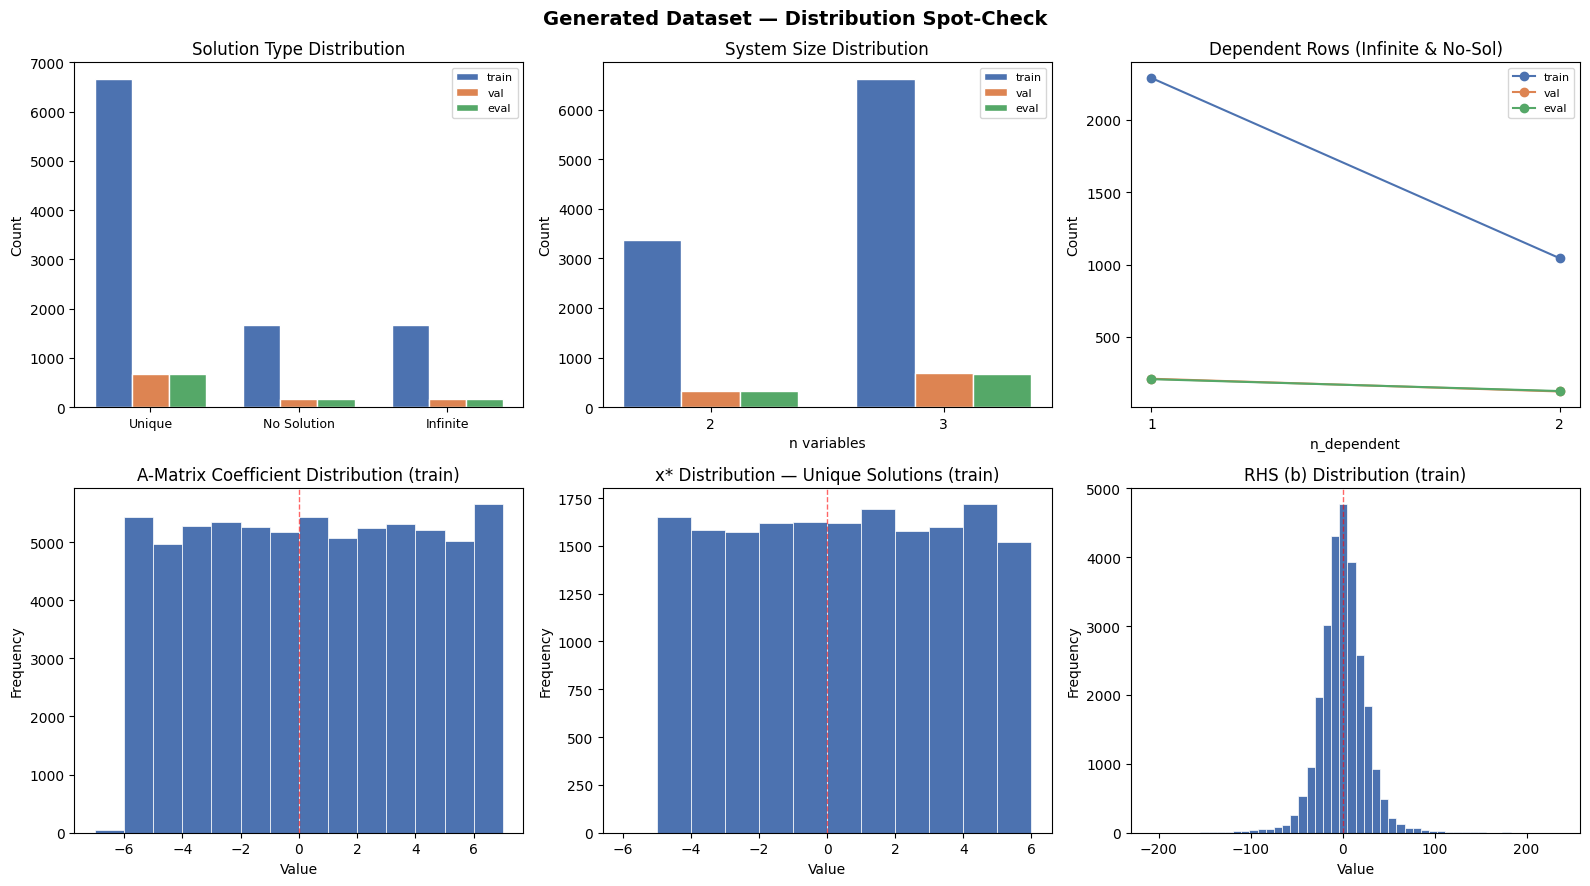

Saved: dataset_distributions.png


In [39]:
all_splits = {'train': train_meta, 'val': val_meta, 'eval': eval_meta}
colors     = {'train': '#4C72B0', 'val': '#DD8452', 'eval': '#55A868'}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Generated Dataset — Distribution Spot-Check', fontsize=14, fontweight='bold')

SOL_TYPES   = ['unique', 'no_solution', 'infinite']
SOL_LABELS  = ['Unique', 'No Solution', 'Infinite']
VAR_RANGE   = list(range(N_VARS_MIN, N_VARS_MAX + 1))

# ── 1. Solution-type distribution ────────────────────────────────────────────
ax = axes[0, 0]
x = np.arange(len(SOL_TYPES))
w = 0.25
for k, (split, meta) in enumerate(all_splits.items()):
    c = Counter(m['solution_type'] for m in meta)
    ax.bar(x + k * w, [c[t] for t in SOL_TYPES], w,
           label=split, color=colors[split], edgecolor='white')
ax.set_xticks(x + w);  ax.set_xticklabels(SOL_LABELS, fontsize=9)
ax.set_title('Solution Type Distribution');  ax.set_ylabel('Count')
ax.legend(fontsize=8)

# ── 2. n_vars distribution ────────────────────────────────────────────────────
ax = axes[0, 1]
x = np.arange(len(VAR_RANGE))
for k, (split, meta) in enumerate(all_splits.items()):
    c = Counter(m['n_vars'] for m in meta)
    ax.bar(x + k * w, [c[n] for n in VAR_RANGE], w,
           label=split, color=colors[split], edgecolor='white')
ax.set_xticks(x + w);  ax.set_xticklabels([str(n) for n in VAR_RANGE])
ax.set_title('System Size Distribution');  ax.set_xlabel('n variables');  ax.set_ylabel('Count')
ax.legend(fontsize=8)

# ── 3. n_dependent distribution (infinite + no_solution only) ─────────────────
ax = axes[0, 2]
for split, meta in all_splits.items():
    deps = [m['n_dependent'] for m in meta if m['solution_type'] != 'unique']
    if deps:
        c    = Counter(deps)
        vals = sorted(c)
        ax.plot(vals, [c[v] for v in vals], 'o-', label=split, color=colors[split])
ax.set_title('Dependent Rows (Infinite & No-Sol)');  ax.set_xlabel('n_dependent')
ax.set_ylabel('Count');  ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.legend(fontsize=8)

# ── 4. A-matrix coefficient histogram ────────────────────────────────────────
ax = axes[1, 0]
coeffs = [c for m in train_meta for c in m['coefficients']]
bins   = range(COEFF_RANGE[0] - 1, COEFF_RANGE[1] + 1)
ax.hist(coeffs, bins=bins, color=colors['train'], edgecolor='white', linewidth=0.5)
ax.axvline(0, color='red', linestyle='--', alpha=0.6, linewidth=1)
ax.set_title('A-Matrix Coefficient Distribution (train)');  ax.set_xlabel('Value')
ax.set_ylabel('Frequency')

# ── 5. x* distribution (unique solutions only) ────────────────────────────────
ax = axes[1, 1]
xstar = [v for m in train_meta if m['x_star'] for v in m['x_star']]
bins  = range(X_STAR_RANGE[0] - 1, X_STAR_RANGE[1] + 1)
ax.hist(xstar, bins=bins, color=colors['train'], edgecolor='white', linewidth=0.5)
ax.axvline(0, color='red', linestyle='--', alpha=0.6, linewidth=1)
ax.set_title('x* Distribution — Unique Solutions (train)');  ax.set_xlabel('Value')
ax.set_ylabel('Frequency')

# ── 6. RHS (b) value distribution ────────────────────────────────────────────
ax = axes[1, 2]
bvals = [v for m in train_meta for v in m['b_values']]
ax.hist(bvals, bins=50, color=colors['train'], edgecolor='white', linewidth=0.5)
ax.axvline(0, color='red', linestyle='--', alpha=0.6, linewidth=1)
ax.set_title('RHS (b) Distribution (train)');  ax.set_xlabel('Value')
ax.set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('dataset_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: dataset_distributions.png')

In [40]:
# ── Print sample problems for each solution type ─────────────────────────────
# NOTE: eval records store the user-visible problem at messages[1]['content'],
# not in a 'system_text' field. Reference it from the messages list.
# N_SAMPLES is configured in Section 0.1.
print(f'Showing {N_SAMPLES} samples per solution type from the training eval records.')

for sol_type in ['unique', 'no_solution', 'infinite']:
    print(f'\n{"=" * 62}')
    print(f'  {sol_type.upper().replace("_", " ")}')
    print(f'{"=" * 62}')
    samples = [r for r in train_eval if r['solution_type'] == sol_type][:N_SAMPLES]
    for i, s in enumerate(samples, 1):
        indent = '    '
        problem = s['messages'][1]['content']
        problem_indented = problem.replace('\n', f'\n{indent}')
        print(f'\n  Example {i}  (n={s["n_vars"]}, n_dep={s["n_dependent"]})')
        print(f'  Problem:')
        print(f'{indent}{problem_indented}')
        answer_indented = s["answer"].replace('\n', f'\n{indent}')
        print(f'  Expected answer: \n{indent}{answer_indented}')


Showing 2 samples per solution type from the training eval records.

  UNIQUE

  Example 1  (n=3, n_dep=0)
  Problem:
    3x - 5y - z = 18
    -3x - 5y - 2z = 8
    -4x - y + 4z = -14
  Expected answer: 
    x=2, y=-2, z=-2

  Example 2  (n=2, n_dep=0)
  Problem:
    -2y = -2
    5x + 4y = 19
  Expected answer: 
    x=3, y=1

  NO SOLUTION

  Example 1  (n=3, n_dep=1)
  Problem:
    -3x - 6y = -24
    -2x - 2y + 5z = -24
    -9x - 12y + 15z = -108
  Expected answer: 
    NO SOLUTION

  Example 2  (n=3, n_dep=2)
  Problem:
    -4x + y - 3z = 35
    8x - 2y + 6z = -73
    12x - 3y + 9z = -105
  Expected answer: 
    NO SOLUTION

  INFINITE

  Example 1  (n=2, n_dep=1)
  Problem:
    -6x + 2y = -4
    -6x + 2y = -4
  Expected answer: 
    INFINITE

  Example 2  (n=2, n_dep=1)
  Problem:
    8x - 2y = -10
    4x - y = -5
  Expected answer: 
    INFINITE


## Section 0.7 — Grading & Reward Functions

These functions are used for:

1. **Now** — offline evaluation of the base model (Section 0.7 or a separate
   eval notebook), providing the baseline before any fine-tuning.
2. **Phase 2 / 3** — as the reward signal for online RL (PPO) and for
   constructing the RFT grader config.

`parse_model_output` is deliberately lenient on formatting (variable order,
spacing) but strict on completeness (all variables must appear for a unique
solution).

`compute_reward` verifies unique solutions by substitution (`A @ x_hat ≈ b`),
not by comparing parsed values to the stored `x_star`.  This is correct because
the stored `x_star` is one particular solution — the model may find a different
representation if the system is somehow underdetermined (shouldn't happen for
unique systems, but substitution is the rigorous check).

`RFT_GRADER_STUB` will be wired into the `fine_tuning.jobs.create` call in
Section 4.3 once the RFT phase begins.

In [41]:
# ---------------------------------------------------------------------------
# Parsing
# ---------------------------------------------------------------------------

def _parse_model_output_impl(text, n_vars):
    # Core parser: operates on text that has already been extracted by
    # _extract_for_parsing (ANSWER: delimiter stripped when INCLUDE_REASONING).
    # Tries the last non-empty line first, then falls back to the full response.
    if not text or not text.strip():
        return 'unparseable', None

    lines = [l.strip() for l in text.strip().splitlines() if l.strip()]
    candidates = []
    if lines:
        candidates.append(lines[-1])
    candidates.append(text.strip())

    no_sol_pat = re.compile(
        r'no[\s_-]?solutions?(?:\s+exists?)?|inconsistent',
        re.IGNORECASE
    )
    infinite_pat = re.compile(
        r'\binfinite(?:ly)?(?:\s+many)?(?:\s+solutions?)?\b',
        re.IGNORECASE
    )

    for cand in candidates:
        cand_stripped = cand.rstrip('.,;:!? ')
        if re.search(no_sol_pat, cand_stripped):
            return 'no_solution', None
        if re.search(infinite_pat, cand_stripped):
            return 'infinite', None

    var_names = VARIABLES[:n_vars]
    for cand in candidates:
        assignments = {}
        for v in var_names:
            m = re.search(v + r'\s*=\s*(-?\d+)', cand, re.IGNORECASE)
            if m:
                assignments[v] = int(m.group(1))
        if len(assignments) == n_vars:
            return 'unique', assignments

    return 'unparseable', None


def _extract_for_parsing(text):
    # When INCLUDE_REASONING is on, extract the content after the ANSWER: delimiter.
    # Falls back to the full text if no delimiter is found (backward compatible).
    if INCLUDE_REASONING:
        m = re.search(r'(?:^|\n)ANSWER:\s*(.+)', text, re.IGNORECASE)
        if m:
            return m.group(1).strip()
    return text


def parse_model_output(text, n_vars):
    # Parse raw model output into (solution_type, assignments).
    # Automatically handles both direct-answer and reasoning-trace formats
    # depending on INCLUDE_REASONING.
    return _parse_model_output_impl(_extract_for_parsing(text), n_vars)


# ---------------------------------------------------------------------------
# Reward
# ---------------------------------------------------------------------------

def compute_reward(pred_type, pred_vals, true_type, A, b, n_vars):
    # Binary +/-1.0 reward.
    # Unique solutions verified by substitution (residual < _RESIDUAL_TOL).
    if pred_type != true_type:
        return -1.0

    if true_type == 'unique':
        if pred_vals is None:
            return -1.0
        A_f   = np.array(A, dtype=float)
        b_f   = np.array(b, dtype=float)
        x_hat = np.array([pred_vals.get(v, 0) for v in VARIABLES[:n_vars]], dtype=float)
        residual = float(np.max(np.abs(A_f @ x_hat - b_f)))
        return 1.0 if residual < _RESIDUAL_TOL else -1.0

    return 1.0   # no_solution or infinite: type match is sufficient


def evaluate_batch(eval_records, model_outputs):
    # Convenience wrapper: score a list of (eval_record, model_output_text) pairs.
    results = []
    for rec, output in zip(eval_records, model_outputs):
        n     = rec['n_vars']
        ptype, pvals = parse_model_output(output, n)
        rew   = compute_reward(ptype, pvals, rec['solution_type'],
                               rec['A'], rec['b'], n)
        results.append({
            'solution_type': rec['solution_type'],
            'n_vars':        n,
            'pred_type':     ptype,
            'reward':        rew,
            'raw_output':    output,
        })
    return results


print('Grading functions loaded.')
print('  parse_model_output(text, n_vars)  ->  (solution_type, assignments | None)')
print('  compute_reward(pred_type, pred_vals, true_type, A, b, n_vars)  ->  +/-1.0')
print('  evaluate_batch(eval_records, model_outputs)  ->  list[result_dict]')
print(f'  INCLUDE_REASONING={INCLUDE_REASONING}: parser uses',
      'ANSWER: delimiter extraction' if INCLUDE_REASONING else 'direct parsing (no delimiter)')


Grading functions loaded.
  parse_model_output(text, n_vars)  ->  (solution_type, assignments | None)
  compute_reward(pred_type, pred_vals, true_type, A, b, n_vars)  ->  +/-1.0
  evaluate_batch(eval_records, model_outputs)  ->  list[result_dict]
  INCLUDE_REASONING=False: parser uses direct parsing (no delimiter)


## Section 0.8 — Offline Eval Harness

Runs any deployed model over `eval.jsonl` and produces a structured report.
Used twice:

| Call site | Model under test | When |
|-----------|------------------|------|
| **Section 2.5** | Base `gpt-4.1-nano` deployment | *Before* fine-tuning — baseline numbers |
| **Section 7.5** | Fine-tuned deployment          | *After*  SFT finishes — comparison     |

Design choices:

* **Concurrent requests** (`ThreadPoolExecutor`, `MAX_WORKERS` default 16). Serial
  calls on 6 000 examples would take hours. Turn workers down to 4–8 if you hit
  HTTP 429 rate-limit errors.
* **Checkpointing** — raw outputs are streamed to `eval_results_<tag>.jsonl` as
  they arrive, so a crash mid-run is recoverable and a re-run with the same
  tag resumes where it stopped.
* **Deterministic decoding** — `temperature=0`, `max_tokens=80`. The task has a
  single correct answer per input; sampling adds noise without value.
* **Reporting** — overall accuracy, per-`solution_type`, per-`n_vars`, plus a
  `pred_type × true_type` confusion matrix. The confusion matrix is the most
  informative view: it reveals *how* the model fails (e.g., hallucinating
  unique solutions on INFINITE systems).


In [42]:
import time
from concurrent.futures import ThreadPoolExecutor, as_completed

# ── Tunables ──────────────────────────────────────────────────────────────────
MAX_WORKERS      = 2     # Concurrent API calls. Lower to 4–8 on 429s.
PRINT_EVERY      = 100    # Progress heartbeat (examples processed).
FAIL_FAST_AFTER  = 20     # Abort if the first N consecutive results are errors.


def _score_one(client, deployment_name, record):
    """Query the deployed model on one eval record; return a result dict."""
    raw, err = '', None
    for attempt in range(5):
        try:
            resp = client.chat.completions.create(
                model       = deployment_name,
                messages    = record['messages'],
                max_tokens  = REASONING_MAX_TOKENS if INCLUDE_REASONING else MAX_TOKENS,
                temperature = TEMPERATURE,
                timeout     = REQUEST_TIMEOUT,   # ← prevents infinite hangs
            )
            raw = resp.choices[0].message.content or ''
            err = None
            break
        except Exception as e:
            err = f'{type(e).__name__}: {e}'
            if '429' in str(e) or 'rate' in str(e).lower():
                time.sleep(2 ** attempt)   # 1s, 2s, 4s, 8s, 16s
                continue
            break   # non-retryable (auth, timeout, bad deployment) — fail fast

    n = record['n_vars']
    pred_type, pred_vals = parse_model_output(raw, n)
    reward = -1.0 if err is not None else compute_reward(
        pred_type, pred_vals, record['solution_type'], record['A'], record['b'], n
    )

    return {
        'solution_type': record['solution_type'],
        'n_vars':        n,
        'n_dependent':   record['n_dependent'],
        'pred_type':     pred_type,
        'reward':        reward,
        'raw_output':    raw,
        'expected':      record['answer'],
        'error':         err,
    }


def run_eval(client, deployment_name, eval_records, tag, resume=True):
    """
    Run `eval_records` through `deployment_name` with concurrency and checkpointing.

    Writes results to `eval_results_<tag>.jsonl` as they arrive. If the file
    already exists and resume=True, examples already scored are skipped.

    Fail-fast: if the first FAIL_FAST_AFTER consecutive results are all errors
    (e.g. wrong deployment name, auth failure, endpoint typo), raises
    RuntimeError immediately instead of burning through all 6k calls.

    Returns
    -------
    list[dict] — one result per record, in the same order as `eval_records`.
    """
    out_path = f'eval_results_{tag}.jsonl'

    # ── Resume support: figure out which indices are already done ───────────
    done = {}  # idx -> result dict
    if resume and os.path.exists(out_path):
        with open(out_path, encoding='utf-8') as f:
            for line in f:
                if not line.strip():
                    continue
                r = json.loads(line)
                done[r['_idx']] = r
        print(f'  [{tag}] resuming: {len(done)} / {len(eval_records)} already scored')

    todo = [i for i in range(len(eval_records)) if i not in done]
    if not todo:
        print(f'  [{tag}] nothing to do — all {len(eval_records)} already scored')
        return [done[i] for i in range(len(eval_records))]

    print(f'  [{tag}] scoring {len(todo)} examples with {MAX_WORKERS} workers ...')
    t0 = time.time()
    n_done = 0
    consec_errors = 0   # streak of consecutive error results

    # Append mode — checkpointing
    with open(out_path, 'a', encoding='utf-8') as fout:
        with ThreadPoolExecutor(max_workers=MAX_WORKERS) as ex:
            futures = {
                ex.submit(_score_one, client, deployment_name, eval_records[i]): i
                for i in todo
            }
            for fut in as_completed(futures):
                i = futures[fut]
                result = fut.result()
                result['_idx'] = i
                done[i] = result
                fout.write(json.dumps(result) + '\n')
                fout.flush()
                n_done += 1

                # ── Fail-fast guard ──────────────────────────────────────────
                # If the first FAIL_FAST_AFTER results are all errors, abort
                # instead of burning through the rest. Any success resets
                # the streak so transient 429s don't trigger it.
                if result['error'] is not None:
                    consec_errors += 1
                else:
                    consec_errors = 0

                if n_done >= FAIL_FAST_AFTER and consec_errors >= FAIL_FAST_AFTER:
                    last_err = result['error']
                    raise RuntimeError(
                        f'[{tag}] aborting: first {FAIL_FAST_AFTER} consecutive '
                        f'results were all errors. Most recent: {last_err}\n'
                        f'Check EVAL_DEPLOYMENT_NAME, API key, and endpoint.\n'
                        f'Delete {out_path} before retrying.'
                    )

                if n_done % PRINT_EVERY == 0 or n_done == len(todo):
                    rate     = n_done / (time.time() - t0 + 1e-9)
                    n_errors = sum(1 for r in done.values() if r.get('error'))
                    print(f'    {n_done:>5}/{len(todo)}  '
                          f'({rate:.1f} ex/s, {time.time() - t0:.1f}s elapsed, '
                          f'{n_errors} errors so far)')

    # Return in original order
    return [done[i] for i in range(len(eval_records))]


def summarize(results, label):
    """Print overall / per-type / per-n_vars / confusion breakdowns."""
    n = len(results)
    errors = sum(1 for r in results if r.get('error'))
    correct = sum(1 for r in results if r['reward'] > 0)

    print(f'\n{"=" * 72}')
    print(f'  EVAL REPORT — {label}   (n={n})')
    print(f'{"=" * 72}')
    print(f'Overall accuracy : {correct}/{n} = {correct/n:.3f}')
    if errors:
        print(f'API errors       : {errors}  (counted as incorrect)')

    # ── By solution type ─────────────────────────────────────────────────────
    print(f'\nBy solution type:')
    print(f'  {"type":<14} {"n":>6} {"correct":>9} {"acc":>7}')
    for t in ['unique', 'no_solution', 'infinite']:
        sub = [r for r in results if r['solution_type'] == t]
        if not sub:
            continue
        c = sum(1 for r in sub if r['reward'] > 0)
        print(f'  {t:<14} {len(sub):>6} {c:>9} {c/len(sub):>7.3f}')

    # ── By n_vars ────────────────────────────────────────────────────────────
    print(f'\nBy n_vars:')
    print(f'  {"n_vars":<8} {"n":>6} {"correct":>9} {"acc":>7}')
    for n_v in sorted({r['n_vars'] for r in results}):
        sub = [r for r in results if r['n_vars'] == n_v]
        c = sum(1 for r in sub if r['reward'] > 0)
        print(f'  {n_v:<8} {len(sub):>6} {c:>9} {c/len(sub):>7.3f}')

    # ── Confusion matrix: true_type × pred_type ──────────────────────────────
    types = ['unique', 'no_solution', 'infinite', 'unparseable']
    cm = {t: Counter() for t in ['unique', 'no_solution', 'infinite']}
    for r in results:
        cm[r['solution_type']][r['pred_type']] += 1

    print(f'\nConfusion matrix (rows = true, cols = predicted):')
    header = f'  {"true \\ pred":<14}' + ''.join(f'{t:>13}' for t in types) + f'{"total":>8}'
    print(header)
    for t in ['unique', 'no_solution', 'infinite']:
        row_total = sum(cm[t].values())
        row = f'  {t:<14}' + ''.join(f'{cm[t][p]:>13}' for p in types) + f'{row_total:>8}'
        print(row)

    # ── By n_vars × solution_type (hardest-cell view) ────────────────────────
    print(f'\nAccuracy by (n_vars, solution_type):')
    print(f'  {"n_vars":<8}' + ''.join(f'{t:>14}' for t in ['unique', 'no_solution', 'infinite']))
    for n_v in sorted({r['n_vars'] for r in results}):
        row = f'  {n_v:<8}'
        for t in ['unique', 'no_solution', 'infinite']:
            sub = [r for r in results if r['n_vars'] == n_v and r['solution_type'] == t]
            if sub:
                c = sum(1 for r in sub if r['reward'] > 0)
                row += f'{c/len(sub):>13.3f} '
            else:
                row += f'{"—":>13} '
        print(row)

    # Return structured aggregates for downstream comparison
    return {
        'label':    label,
        'n':        n,
        'accuracy': correct / n,
        'errors':   errors,
        'by_type':  {t: {
            'n': sum(1 for r in results if r['solution_type'] == t),
            'correct': sum(1 for r in results if r['solution_type'] == t and r['reward'] > 0),
        } for t in ['unique', 'no_solution', 'infinite']},
        'by_n_vars': {n_v: {
            'n': sum(1 for r in results if r['n_vars'] == n_v),
            'correct': sum(1 for r in results if r['n_vars'] == n_v and r['reward'] > 0),
        } for n_v in sorted({r['n_vars'] for r in results})},
    }


def assert_eval_healthy(results, tag, max_error_rate=0.05):
    """
    Raise if more than max_error_rate of results are API errors.

    Call this right after run_eval() + summarize(). Prevents silently
    recording a garbage eval (e.g., the 0/6000 case where every call
    hit APIConnectionError and was scored as -1).
    """
    n = len(results)
    err_count = sum(1 for r in results if r.get('error'))
    err_rate = err_count / n if n else 0.0
    print(f'[{tag}] health check: {err_count}/{n} errors ({err_rate:.1%})')
    if err_rate > max_error_rate:
        top = Counter(r['error'] for r in results if r.get('error')).most_common(3)
        raise RuntimeError(
            f'[{tag}] eval is unhealthy: {err_rate:.1%} error rate '
            f'(>{max_error_rate:.0%} threshold).\n'
            f'Top errors: {top}\n'
            f'Delete eval_results_{tag}.jsonl and fix the root cause before re-running.'
        )
    print(f'[{tag}] healthy — proceed')



def fetch_training_metadata(client, fine_tuned_model_name):
    """
    Search Azure fine-tuning jobs for one whose fine_tuned_model field matches
    fine_tuned_model_name.  Returns a metadata dict, or None for baseline models.

    Available fields: job_id, base_model, method (supervised/dpo/reinforcement),
    hyperparameters, training_file, validation_file, trained_tokens, timestamps.
    """
    try:
        for job in client.fine_tuning.jobs.list():
            if job.fine_tuned_model == fine_tuned_model_name:
                hp = job.hyperparameters
                return {
                    'job_id':           job.id,
                    'base_model':       job.model,
                    'method':           str(job.method),
                    'hyperparameters': {
                        'n_epochs':                 hp.n_epochs,
                        'batch_size':               hp.batch_size,
                        'learning_rate_multiplier': hp.learning_rate_multiplier,
                    },
                    'training_file':    job.training_file,
                    'validation_file':  job.validation_file,
                    'trained_tokens':   job.trained_tokens,
                    'created_at':       job.created_at,
                    'finished_at':      job.finished_at,
                    'seed':             getattr(job, 'seed', None),
                    'status':           job.status,
                }
    except Exception as e:
        print(f'  [fetch_training_metadata] warning: {e}')
    return None


print('Eval harness loaded (v2, fail-fast).')
print('  run_eval(client, deployment_name, eval_records, tag, resume=True)  ->  list[result]')
print('     └─ aborts if first', FAIL_FAST_AFTER, 'consecutive results are all errors')
print('  summarize(results, label)                                          ->  dict of aggregates')
print('  assert_eval_healthy(results, tag, max_error_rate=0.05)             ->  raises if unhealthy')
print('  fetch_training_metadata(client, model_name)                          ->  metadata dict or None')


Eval harness loaded (v2, fail-fast).
  run_eval(client, deployment_name, eval_records, tag, resume=True)  ->  list[result]
     └─ aborts if first 20 consecutive results are all errors
  summarize(results, label)                                          ->  dict of aggregates
  assert_eval_healthy(results, tag, max_error_rate=0.05)             ->  raises if unhealthy
  fetch_training_metadata(client, model_name)                          ->  metadata dict or None


---

## Section 0 → Sections 1–8 Reference Table

The table below lists every variable and file that the fine-tuning workflow
(Sections 1–8) inherits from the data generation pipeline (Section 0).
Use it to answer: *"which cells do I need to re-run in a fresh runtime?"*

| Name | Kind | What it represents | Persisted? | Used by |
|------|------|--------------------|-----------|---------|
| `training.jsonl` | File | 30 000 SFT chat records (10 000 × 3 solution types) | ✅ Disk | §3 — upload to Azure |
| `validation.jsonl` | File | 3 000 SFT validation records | ✅ Disk | §3 — upload to Azure |
| `eval.jsonl` | File | 6 000 held-out eval records with `A`, `b`, `answer`, metadata | ✅ Disk | §2.5.2 (loader), §7, §7.5 |
| `held_out_eval` | Runtime variable | Python list of the 6 000 eval dicts; mirror of `eval.jsonl` | ⚠️ Runtime | §2.5.1, §7, §7.5 — reload via §2.5.2 if lost |
| `SYSTEM_PROMPT` | Runtime variable | Exact system prompt injected into every model call | ⚠️ Runtime | §0.8 harness, §2.5, §7.5 |
| `TRAIN_JSONL`, `VAL_JSONL`, `EVAL_JSONL` | Runtime variables | File path strings (`'training.jsonl'`, etc.) | ⚠️ Runtime | §0.5 (write), §3 (read) |
| `parse_model_output` | Runtime function | Parses raw model text → `(solution_type, assignments)` | ⚠️ Runtime | §0.8, §2.5, §7, §7.5 |
| `compute_reward` | Runtime function | Returns ±1.0 reward; unique solutions verified by substitution | ⚠️ Runtime | §0.8, §2.5, §7, §7.5 |
| `run_eval` / `summarize` | Runtime functions | Concurrent eval loop + aggregated reporting | ⚠️ Runtime | §2.5.1, §7.5 |
| `RFT_GRADER_STUB` | Runtime variable | Grader config dict for the RFT fine-tuning job | ⚠️ Runtime | §4.3 only |

> **Files (✅ Disk)** survive runtime restarts — run Section 0 once per machine.
> **Runtime variables (⚠️)** are lost on restart — see each section's
> *Prerequisites* note for the minimal set of cells to re-run before continuing.


---

# Sections 1 – 8 — Azure Fine-Tuning Workflow

The cells below are the original TA-provided fine-tuning notebook.

> **Prerequisites:** Run all of Section 0 first.  `training.jsonl` and
> `validation.jsonl` must exist on disk before reaching Section 3.

## 1 — Setup and Installation

> **Prerequisites:** None — safe to run in any fresh runtime.  Installs all
> Python packages needed for both the data-generation and fine-tuning sections.


In [43]:
%pip install -q \
  "azure-ai-projects>=2.0.0b1" \
  openai \
  azure-identity \
  azure-mgmt-cognitiveservices \
  "azure-ai-evaluation>=1.13.0" \
  python-dotenv

## 2 — Configure Azure

This sets up the Azure credential authentication and initializes the OpenAI
client needed for fine-tuning workflows.

> **Prerequisites:** Section 1 (package installation) must have run.  Edit the
> constants in **Section 2.2** below before running further cells.


### 2.1 — Import Azure Modules


In [44]:
import os
from openai import AzureOpenAI
from azure.identity import DefaultAzureCredential
from azure.mgmt.cognitiveservices import CognitiveServicesManagementClient
from azure.mgmt.cognitiveservices.models import Deployment, DeploymentProperties, DeploymentModel, Sku

### 2.2 — Set Azure Constants

> ⚠️ **Edit the values below before running.**  `OPENAI_API_KEY` and
> `SUBSCRIPTION_ID` are team-specific credentials.  In a shared or
> version-controlled environment, load these from a `.env` file or environment
> variables rather than hardcoding them here.


In [45]:
# TODO: Update RESOURCE_GROUP and OPENAI_API_KEY provided to your team via Gradescope.
# Do not modify other fields.
RESOURCE_GROUP   = 'cis-5270-team-11'
OPENAI_API_KEY   = 'TODO: INSERT AZURE OPENAI API KEY'  # ← load from .env in a real project
OPENAI_ENDPOINT  = f'https://{RESOURCE_GROUP}.openai.azure.com'
SUBSCRIPTION_ID  = '5878da59-4f37-415e-bc8c-3a1be9ba0161'  # ← load from .env in a real project


### 2.3 — Authenticate & Initialize Client


In [46]:
# Azure resource targeting
os.environ['AZURE_SUBSCRIPTION_ID'] = SUBSCRIPTION_ID
os.environ['AZURE_RESOURCE_GROUP']  = 'CIS-5270'
os.environ['AZURE_AOAI_ACCOUNT']    = RESOURCE_GROUP
os.environ['AZURE_OPENAI_API_KEY']  = OPENAI_API_KEY
os.environ['AZURE_OPENAI_ENDPOINT'] = OPENAI_ENDPOINT
CREDENTIAL = DefaultAzureCredential()

We're using **gpt-4.1-nano** in this example, but you can use other supported GPT models.

In [47]:
openai_client = AzureOpenAI(
    api_key      = OPENAI_API_KEY,
    azure_endpoint = OPENAI_ENDPOINT,
    api_version  = '2025-04-01-preview',
)
model_name = 'gpt-4.1-nano-2025-04-14'
print('Connected to Azure OpenAI')

Connected to Azure OpenAI


## 2.5 — Evaluation

Run any deployed model — baseline or fine-tuned — over the full 6 000-example
`eval.jsonl` held-out set.  Set `EVAL_DEPLOYMENT_NAME` in the config cell below,
then run all cells in this section in order.

> **Fresh-runtime shortcut:** If `eval_results_{EVAL_TAG}.jsonl` already exists
> from a prior session, skip **Section 2.5.1** and go directly to
> **Section 2.5.2** (*Resume From a Previous Run*) — no Azure API calls needed.


In [48]:
# ── Evaluation Config ────────────────────────────────────────────────────────
# Edit the four variables below, then run all cells in this section in order.
#
#   EVAL_DEPLOYMENT_NAME : Azure deployment name to query.
#                          Use the base model name for baseline evals, or the
#                          fine-tuned deployment name from Section 6 afterwards.
#   EVAL_TAG             : Short label used as the file-suffix for all saved
#                          artefacts.  Must be filesystem-safe (letters, digits,
#                          underscores).
#   EVAL_NOTES           : Free-text notes attached to the saved summary JSON.
#   IS_FINETUNED         : Set True to have the save cell fetch Azure training
#                          metadata (hyperparameters, file IDs, job info) from
#                          the Azure fine-tuning API and include it in the JSON.
#
# NOTE: Re-running this cell generates a new _run_id (= fresh run).
#       To resume an interrupted run, do NOT re-run this cell — just re-run
#       the eval cell (2.5.1) directly; it will find the existing checkpoint.
# ─────────────────────────────────────────────────────────────────────────────

EVAL_DEPLOYMENT_NAME = 'gpt-4.1-nano'   # <-- EDIT ME
EVAL_TAG             = 'baseline_REASONING'        # <-- EDIT ME
EVAL_NOTES           = 'baseline on weighted eval set, 1k samples'              # optional free-text notes
IS_FINETUNED         = True            # set True for fine-tuned deployments

import datetime as _dt
_now    = _dt.datetime.now(_dt.timezone.utc)
_run_id = f'{_now.strftime("%Y%m%d_%H%M%S")}_{EVAL_TAG}'

print(f'Eval config set:')
print(f'  EVAL_DEPLOYMENT_NAME = {EVAL_DEPLOYMENT_NAME!r}')
print(f'  EVAL_TAG             = {EVAL_TAG!r}')
print(f'  IS_FINETUNED         = {IS_FINETUNED}')
print(f'  run_id               = {_run_id!r}')


Eval config set:
  EVAL_DEPLOYMENT_NAME = 'gpt-4.1-nano'
  EVAL_TAG             = 'baseline_REASONING'
  IS_FINETUNED         = True
  run_id               = '20260504_230727_baseline_REASONING'


#### 2.5.1 — Run Eval

> **Prerequisites (must be in scope):** `held_out_eval`, `parse_model_output`,
> `compute_reward`, `run_eval`, `summarize`, `assert_eval_healthy`,
> `fetch_training_metadata`, `SYSTEM_PROMPT`, `MAX_WORKERS`, `MAX_TOKENS` —
> run **Sections 0.1 – 0.8** first.  Also requires `openai_client` from
> **Section 2.3**.
>
> Set `EVAL_DEPLOYMENT_NAME` and `EVAL_TAG` in the config cell above before
> running.  Expected runtime: ~10–20 min on 6 000 examples.  Results stream to
> `eval_results_{EVAL_TAG}.jsonl`; re-running resumes from the checkpoint.


In [49]:
# Delete a partial / rate-limited run before starting fresh.
# Only needed if you want to discard the current checkpoint and restart.
import os
_path = f'eval_results_{_run_id}.jsonl'
if os.path.exists(_path):
    os.remove(_path)
    print(f'Deleted: {_path}')
else:
    print(f'Not found (nothing to delete): {_path}')


Not found (nothing to delete): eval_results_20260504_230727_baseline_REASONING.jsonl


In [50]:
print(f'Running eval on {len(held_out_eval)} examples ...')
print(f'  deployment : {EVAL_DEPLOYMENT_NAME}')
print(f'  run_id     : {_run_id}')
print(f'  workers    : {MAX_WORKERS}')

eval_results = run_eval(
    client          = openai_client,
    deployment_name = EVAL_DEPLOYMENT_NAME,
    eval_records    = held_out_eval,
    tag             = _run_id,
)

eval_summary = summarize(eval_results, label=f'{EVAL_TAG.upper()} ({EVAL_DEPLOYMENT_NAME})')


Running eval on 1000 examples ...
  deployment : gpt-4.1-nano
  run_id     : 20260504_230727_baseline_REASONING
  workers    : 2
  [20260504_230727_baseline_REASONING] scoring 1000 examples with 2 workers ...
      100/1000  (2.1 ex/s, 48.7s elapsed, 0 errors so far)
      200/1000  (2.1 ex/s, 96.0s elapsed, 0 errors so far)
      300/1000  (2.1 ex/s, 142.5s elapsed, 0 errors so far)
      400/1000  (2.1 ex/s, 189.4s elapsed, 0 errors so far)
      500/1000  (2.1 ex/s, 235.0s elapsed, 0 errors so far)
      600/1000  (2.1 ex/s, 281.5s elapsed, 0 errors so far)
      700/1000  (2.1 ex/s, 329.3s elapsed, 0 errors so far)
      800/1000  (2.1 ex/s, 376.2s elapsed, 0 errors so far)
      900/1000  (2.1 ex/s, 423.2s elapsed, 0 errors so far)
     1000/1000  (2.1 ex/s, 470.8s elapsed, 0 errors so far)

  EVAL REPORT — BASELINE_REASONING (gpt-4.1-nano)   (n=1000)
Overall accuracy : 210/1000 = 0.210

By solution type:
  type                n   correct     acc
  unique            666        37 

In [51]:
# Raise if more than 5 % of calls returned an API error — prevents silently
# recording a near-zero-accuracy eval from a broken deployment.
assert_eval_healthy(eval_results, tag=_run_id)


[20260504_230727_baseline_REASONING] health check: 0/1000 errors (0.0%)
[20260504_230727_baseline_REASONING] healthy — proceed


#### 2.5.2 — ⚡ Resume From a Previous Run

> **Use this cell instead of 2.5.1 when** `eval_results_{EVAL_TAG}.jsonl` already
> exists on disk from a prior session and you do not want to re-run the eval.
>
> **Still required in this session:** run **Sections 0.1 and 0.7–0.8** (no API
> calls) so that `VARIABLES`, `parse_model_output`, and `compute_reward` are
> defined.  Also run the **config cell** at the top of Section 2.5 to set
> `EVAL_TAG`.  Then continue from **Section 2.5.3** onwards.


In [52]:
# Fresh-runtime loader — run this cell INSTEAD of Section 2.5.1 if
# eval_results_{_run_id}.jsonl already exists from a prior session.
#
# Requirements:
#   • eval_results_{_run_id}.jsonl  — written by run_eval() in Section 2.5.1
#   • eval.jsonl                    — written by Section 0.5
#   • Sections 0.1 and 0.7–0.8 already executed (defines VARIABLES,
#     parse_model_output, compute_reward, etc.)
#   • Config cell at top of Section 2.5 executed (sets EVAL_TAG, _run_id, etc.)
# ─────────────────────────────────────────────────────────────────────────────

import json, os

# ── 1. Load eval_results from the on-disk checkpoint ─────────────────────────
_results_path = f'eval_results_{_run_id}.jsonl'

if not os.path.exists(_results_path):
    raise FileNotFoundError(
        f"{_results_path!r} not found. "
        "Either run the eval (Section 2.5.1) or check that the eval config "
        "cell has been run with the correct EVAL_TAG so _run_id matches."
    )

_raw_rows = {}
with open(_results_path, encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        r = json.loads(line)
        _raw_rows[r['_idx']] = r

eval_results = [_raw_rows[i] for i in range(len(_raw_rows))]
print(f"Loaded eval_results: {len(eval_results)} rows from {_results_path!r}")

# ── 2. Reconstruct held_out_eval from eval.jsonl ──────────────────────────────
_eval_path = 'eval.jsonl'

if not os.path.exists(_eval_path):
    raise FileNotFoundError(
        f"{_eval_path!r} not found. Run Section 0 (data generation) first."
    )

held_out_eval = []
with open(_eval_path, encoding='utf-8-sig') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        held_out_eval.append(json.loads(line))

print(f"Loaded held_out_eval:    {len(held_out_eval)} records from {_eval_path!r}")

# ── 3. Rebuild eval_summary ───────────────────────────────────────────────────
eval_summary = summarize(eval_results, label=f'{EVAL_TAG.upper()} ({EVAL_DEPLOYMENT_NAME})')

print()
print("Ready to run Sections 2.5.3 onwards.")


Loaded eval_results: 1000 rows from 'eval_results_20260504_230727_baseline_REASONING.jsonl'
Loaded held_out_eval:    1000 records from 'eval.jsonl'

  EVAL REPORT — BASELINE_REASONING (gpt-4.1-nano)   (n=1000)
Overall accuracy : 210/1000 = 0.210

By solution type:
  type                n   correct     acc
  unique            666        37   0.056
  no_solution       167       118   0.707
  infinite          167        55   0.329

By n_vars:
  n_vars        n   correct     acc
  2           324       103   0.318
  3           676       107   0.158

Confusion matrix (rows = true, cols = predicted):
  true \ pred          unique  no_solution     infinite  unparseable   total
  unique                  539          119            8            0     666
  no_solution              35          118           11            3     167
  infinite                 61           44           55            7     167

Accuracy by (n_vars, solution_type):
  n_vars          unique   no_solution      infini

#### 2.5.3 — Outcome & Unparseable Analysis

Breakdown of model outputs: how many were correct, wrong-but-parseable,
or unparseable — and what kinds of unparseable responses were produced.


Overall baseline outcome breakdown:
  correct          210  (21.0%)
  wrong_type       780  (78.0%)
  unparseable       10  (1.0%)


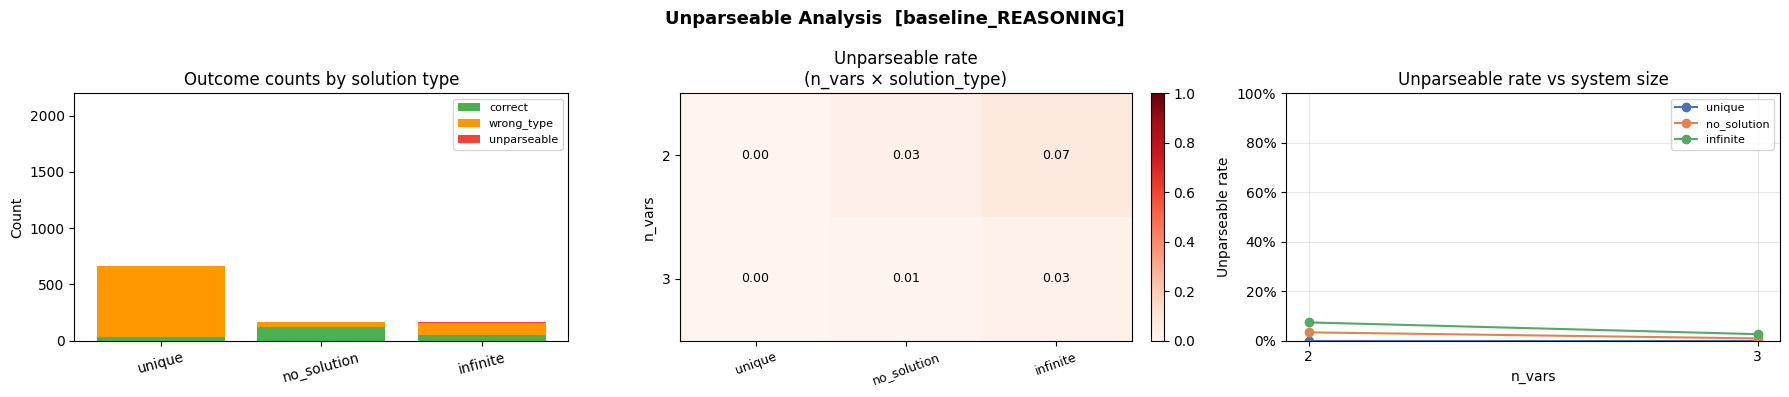

Saved: eval_unparseable_breakdown_baseline_REASONING.png


In [53]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from collections import Counter

# ── 1.  Overall outcome breakdown ─────────────────────────────────────────────
outcome_labels = ['correct', 'wrong_type', 'unparseable']

def outcome(r):
    if r['pred_type'] == 'unparseable':
        return 'unparseable'
    if r['reward'] > 0:
        return 'correct'
    return 'wrong_type'

overall_counts = Counter(outcome(r) for r in eval_results)
print("Overall baseline outcome breakdown:")
for lbl in outcome_labels:
    n = overall_counts[lbl]
    print(f"  {lbl:<14} {n:>5}  ({n/len(eval_results):.1%})")

# ── 2.  Unparseable rate by solution type × n_vars ────────────────────────────
SOL_TYPES  = ['unique', 'no_solution', 'infinite']
N_VAR_VALS = sorted({r['n_vars'] for r in eval_results})

unparse_rate = np.zeros((len(N_VAR_VALS), len(SOL_TYPES)))
for i, nv in enumerate(N_VAR_VALS):
    for j, st in enumerate(SOL_TYPES):
        sub = [r for r in eval_results
               if r['n_vars'] == nv and r['solution_type'] == st]
        if sub:
            unparse_rate[i, j] = sum(
                1 for r in sub if r['pred_type'] == 'unparseable'
            ) / len(sub)

# ── 3.  Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle(f'Unparseable Analysis  [{EVAL_TAG}]', fontsize=13, fontweight='bold')

# Panel 1: stacked bar — outcomes per solution type
ax = axes[0]
colors_outcome = {'correct': '#4CAF50', 'wrong_type': '#FF9800', 'unparseable': '#F44336'}
bot = np.zeros(len(SOL_TYPES))
for lbl in outcome_labels:
    vals = [
        sum(1 for r in eval_results
            if r['solution_type'] == st and outcome(r) == lbl)
        for st in SOL_TYPES
    ]
    ax.bar(SOL_TYPES, vals, bottom=bot, label=lbl, color=colors_outcome[lbl])
    bot += np.array(vals)
ax.set_title('Outcome counts by solution type')
ax.set_ylabel('Count')
ax.set_ylim(0, 2200)
ax.legend(fontsize=8)
ax.yaxis.set_major_locator(mticker.MultipleLocator(500))
for tick in ax.get_xticklabels():
    tick.set_rotation(15)

# Panel 2: unparseable rate heatmap (n_vars × solution_type)
ax = axes[1]
im = ax.imshow(unparse_rate, aspect='auto', cmap='Reds', vmin=0, vmax=1)
ax.set_xticks(range(len(SOL_TYPES)))
ax.set_xticklabels(SOL_TYPES, rotation=20, fontsize=9)
ax.set_yticks(range(len(N_VAR_VALS)))
ax.set_yticklabels(N_VAR_VALS)
ax.set_ylabel('n_vars')
ax.set_title('Unparseable rate\n(n_vars × solution_type)')
for i in range(unparse_rate.shape[0]):
    for j in range(unparse_rate.shape[1]):
        ax.text(j, i, f'{unparse_rate[i,j]:.2f}',
                ha='center', va='center', fontsize=9,
                color='white' if unparse_rate[i,j] > 0.6 else 'black')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# Panel 3: unparseable rate vs n_vars (line per solution type)
ax = axes[2]
line_colors = {'unique': '#4C72B0', 'no_solution': '#DD8452', 'infinite': '#55A868'}
for j, st in enumerate(SOL_TYPES):
    ax.plot(N_VAR_VALS, unparse_rate[:, j], 'o-',
            label=st, color=line_colors[st])
ax.set_xlabel('n_vars')
ax.set_ylabel('Unparseable rate')
ax.set_title('Unparseable rate vs system size')
ax.set_ylim(0, 1)
ax.set_xticks(N_VAR_VALS)
ax.legend(fontsize=8)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'eval_unparseable_breakdown_{EVAL_TAG}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: eval_unparseable_breakdown_{EVAL_TAG}.png')

In [54]:
import re

def categorise_unparseable(raw, n_vars):
    """
    Heuristically label *why* a response was unparseable.

    Categories (checked in priority order):
        'empty'            — the model returned nothing
        'truncated_unique' — has some (but not all) var=int assignments
        'has_infinite_kw'  — contains 'infinite' / 'infinitely many' substring
        'has_nosol_kw'     — contains 'no solution' / 'no_solution' substring
        'chain_of_thought' — long response (>80 chars) with no var=int hits
        'other'
    """
    if not raw or not raw.strip():
        return 'empty'

    text = raw.strip()
    var_names = VARIABLES[:n_vars]

    n_found = sum(
        1 for v in var_names
        if re.search(v + r'\s*=\s*-?\d+', text, re.IGNORECASE)
    )

    if 0 < n_found < n_vars:
        return 'truncated_unique'
    if re.search(r'infinit', text, re.IGNORECASE):
        return 'has_infinite_kw'
    if re.search(r'no[\s_-]?solution|no\s+solutions?', text, re.IGNORECASE):
        return 'has_nosol_kw'
    if len(text) > 80 and n_found == 0:
        return 'chain_of_thought'
    return 'other'


# ── Collect unparseable results ───────────────────────────────────────────────
unparse_results = [r for r in eval_results if r['pred_type'] == 'unparseable']
print(f"Total unparseable: {len(unparse_results)} / {len(eval_results)} "
      f"({len(unparse_results)/len(eval_results):.1%})\n")

# ── Category distribution ─────────────────────────────────────────────────────
cats = Counter(
    categorise_unparseable(r['raw_output'], r['n_vars'])
    for r in unparse_results
)
print("Unparseable response categories:")
for cat, cnt in cats.most_common():
    print(f"  {cat:<22} {cnt:>5}  ({cnt/len(unparse_results):.1%})")

# ── Category breakdown by solution type ───────────────────────────────────────
SOL_TYPES = ['unique', 'no_solution', 'infinite']
print()
cat_order = [c for c, _ in cats.most_common()]
print(f"  {'category':<22}" + "".join(f"{st:>14}" for st in SOL_TYPES))
for cat in cat_order:
    row = f"  {cat:<22}"
    for st in SOL_TYPES:
        sub = [r for r in unparse_results if r['solution_type'] == st]
        n   = sum(1 for r in sub
                  if categorise_unparseable(r['raw_output'], r['n_vars']) == cat)
        row += f"{n:>14}"
    print(row)

# ── Print N concrete examples per solution type ───────────────────────────────
N_EXAMPLES = 5

print(f"\n{'=' * 70}")
print("  UNPARSEABLE EXAMPLES  (raw model output, truncated to 300 chars)")
print(f"{'=' * 70}")

for st in SOL_TYPES:
    sub = [r for r in unparse_results if r['solution_type'] == st]
    print(f"\n── True type: {st.upper()}  ({len(sub)} unparseable) ──")
    for i, r in enumerate(sub[:N_EXAMPLES], 1):
        cat  = categorise_unparseable(r['raw_output'], r['n_vars'])
        disp = repr(r['raw_output'][:300]) + ('...' if len(r['raw_output']) > 300 else '')
        print(f"  [{i}] n_vars={r['n_vars']} | category={cat}")
        print(f"       expected : {r['expected']!r}")
        print(f"       got      : {disp}")

Total unparseable: 10 / 1000 (1.0%)

Unparseable response categories:
  truncated_unique           9  (90.0%)
  other                      1  (10.0%)

  category                      unique   no_solution      infinite
  truncated_unique                   0             3             6
  other                              0             0             1

  UNPARSEABLE EXAMPLES  (raw model output, truncated to 300 chars)

── True type: UNIQUE  (0 unparseable) ──

── True type: NO_SOLUTION  (3 unparseable) ──
  [1] n_vars=3 | category=truncated_unique
       expected : 'NO SOLUTION'
       got      : 'x=3, y=-4'
  [2] n_vars=2 | category=truncated_unique
       expected : 'NO SOLUTION'
       got      : 'x=-17/3'
  [3] n_vars=2 | category=truncated_unique
       expected : 'NO SOLUTION'
       got      : 'x=-5'

── True type: INFINITE  (7 unparseable) ──
  [1] n_vars=3 | category=truncated_unique
       expected : 'INFINITE'
       got      : 'x=2, z=4, y=any'
  [2] n_vars=2 | category=trunc

#### 2.5.4 — Error Analysis

Examines wrong-but-parseable failures: cases where the model returned a
well-formatted answer that was factually incorrect.


In [55]:
# ── Examples of non-unparseable errors ───────────────────────────────────────
# Shows cases where the model gave a parseable answer but was still wrong.

SOL_TYPES  = ['unique', 'no_solution', 'infinite']
N_EXAMPLES = 4

wrong = [r for r in eval_results
         if r['pred_type'] != 'unparseable' and r['reward'] < 0]

print(f"Total wrong-but-parseable: {len(wrong)} / {len(eval_results)} "
      f"({len(wrong)/len(eval_results):.1%})\n")

for true_type in SOL_TYPES:
    sub = [r for r in wrong if r['solution_type'] == true_type]
    print(f"\n{'='*70}")
    print(f"  TRUE TYPE: {true_type.upper()}  ({len(sub)} wrong-but-parseable errors)")
    print(f"{'='*70}")

    # Group by what the model predicted instead
    by_pred = {}
    for r in sub:
        by_pred.setdefault(r['pred_type'], []).append(r)
    print(f"  Predicted as: " +
          ", ".join(f"{pt}={len(rs)}" for pt, rs in sorted(by_pred.items())))

    # Show N_EXAMPLES, preferring variety across predicted types
    shown = []
    for pred_type, rs in sorted(by_pred.items()):
        shown.extend(rs[:max(1, N_EXAMPLES // len(by_pred))])
    shown = shown[:N_EXAMPLES]

    for i, r in enumerate(shown, 1):
        idx = r.get('_idx')
        problem = held_out_eval[idx]['messages'][1]['content'] if idx is not None else '(unavailable)'
        print(f"\n  [{i}]  predicted={r['pred_type']}  n_vars={r['n_vars']}")
        print(f"  ── Input ──")
        for line in problem.strip().splitlines():
            print(f"     {line}")
        print(f"  ── Expected ──  {r['expected']!r}")
        print(f"  ── Got      ──  {r['raw_output']!r}")


Total wrong-but-parseable: 780 / 1000 (78.0%)


  TRUE TYPE: UNIQUE  (629 wrong-but-parseable errors)
  Predicted as: infinite=8, no_solution=119, unique=502

  [1]  predicted=infinite  n_vars=2
  ── Input ──
     2x - y = 4
     2x - 2y = 8
  ── Expected ──  'x=0, y=-4'
  ── Got      ──  'INFINITE'

  [2]  predicted=no_solution  n_vars=3
  ── Input ──
     -3x - 5y + 5z = 10
     -6x + 4y - 2z = -2
     -6x - y + 4z = 11
  ── Expected ──  'x=0, y=1, z=3'
  ── Got      ──  'NO SOLUTION'

  [3]  predicted=unique  n_vars=3
  ── Input ──
     -4x + 5y + 4z = -16
     4x - y + 4z = 0
     -6x - 3y + 4z = -20
  ── Expected ──  'x=2, y=0, z=-2'
  ── Got      ──  'x=2, y=0, z=3'

  TRUE TYPE: NO_SOLUTION  (46 wrong-but-parseable errors)
  Predicted as: infinite=11, unique=35

  [1]  predicted=infinite  n_vars=3
  ── Input ──
     18x - 3y + 6z = 2
     -6x + y - 2z = -2
     6x - y + 2z = 2
  ── Expected ──  'NO SOLUTION'
  ── Got      ──  'INFINITE'

  [2]  predicted=infinite  n_vars=2
  ── 

#### 2.5.5 — Visualizations

Five report-ready figures.  All cells require only `eval_results` — defined
by Section 2.5.1 or reloaded via Section 2.5.2.

| Figure | Saved file | What it shows |
|--------|------------|---------------|
| 1 | `eval_accuracy_overview_{EVAL_TAG}.png` | Outcome breakdown per solution type + accuracy heatmap over n\_vars × solution\_type |
| 2 | `eval_confusion_matrix_{EVAL_TAG}.png` | Normalised and raw-count confusion matrix (true vs predicted type) |
| 3 | `eval_response_length_{EVAL_TAG}.png` | Response length distribution by outcome; truncation diagnostic |
| 4 | `eval_n_vars_breakdown_{EVAL_TAG}.png` | Per-n\_vars outcome breakdown (correct / wrong\_type / unparseable) |
| 5 | `eval_n_dependent_{EVAL_TAG}.png` | Accuracy vs n\_dependent for `infinite` and `no_solution` types |


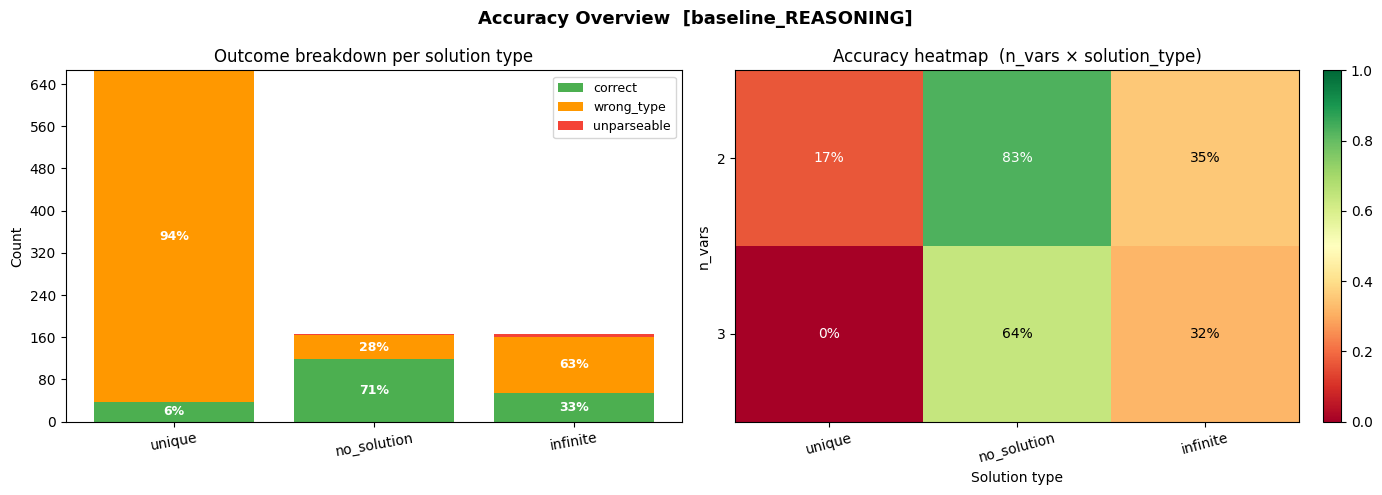

Saved: eval_accuracy_overview_baseline_REASONING.png


In [56]:
# ── Figure 1: Accuracy overview ─────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

_SOL_TYPES  = ['unique', 'no_solution', 'infinite']
_N_VAR_VALS = sorted({r['n_vars'] for r in eval_results})

def _outcome(r):
    if r['pred_type'] == 'unparseable': return 'unparseable'
    if r['reward'] > 0:                 return 'correct'
    return 'wrong_type'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Accuracy Overview  [{EVAL_TAG}]', fontsize=13, fontweight='bold')

# Panel 1 — stacked bar: outcome breakdown per solution type
ax = axes[0]
_ORDER  = ['correct', 'wrong_type', 'unparseable']
_COLORS = {'correct': '#4CAF50', 'wrong_type': '#FF9800', 'unparseable': '#F44336'}
bot = np.zeros(len(_SOL_TYPES))
for lbl in _ORDER:
    vals  = np.array([sum(1 for r in eval_results
                          if r['solution_type'] == st and _outcome(r) == lbl)
                      for st in _SOL_TYPES], dtype=float)
    totals = np.array([sum(1 for r in eval_results if r['solution_type'] == st)
                       for st in _SOL_TYPES])
    ax.bar(_SOL_TYPES, vals, bottom=bot, label=lbl, color=_COLORS[lbl])
    for xi, (v, b, tot) in enumerate(zip(vals, bot, totals)):
        if tot > 0 and v / tot > 0.05:
            ax.text(xi, b + v / 2, f'{v/tot:.0%}',
                    ha='center', va='center', fontsize=9,
                    color='white', fontweight='bold')
    bot += vals
ax.set_ylabel('Count')
ax.set_title('Outcome breakdown per solution type')
ax.legend(fontsize=9, loc='upper right')
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
for tick in ax.get_xticklabels():
    tick.set_rotation(10)

# Panel 2 — heatmap: accuracy (correct rate) over n_vars × solution_type
ax = axes[1]
acc_grid = np.zeros((len(_N_VAR_VALS), len(_SOL_TYPES)))
for i, nv in enumerate(_N_VAR_VALS):
    for j, st in enumerate(_SOL_TYPES):
        sub = [r for r in eval_results if r['n_vars'] == nv and r['solution_type'] == st]
        acc_grid[i, j] = (sum(1 for r in sub if r['reward'] > 0) / len(sub)) if sub else 0.0

im = ax.imshow(acc_grid, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
ax.set_xticks(range(len(_SOL_TYPES))); ax.set_xticklabels(_SOL_TYPES, rotation=15)
ax.set_yticks(range(len(_N_VAR_VALS))); ax.set_yticklabels(_N_VAR_VALS)
ax.set_ylabel('n_vars'); ax.set_xlabel('Solution type')
ax.set_title('Accuracy heatmap  (n_vars × solution_type)')
for i in range(acc_grid.shape[0]):
    for j in range(acc_grid.shape[1]):
        v = acc_grid[i, j]
        ax.text(j, i, f'{v:.0%}', ha='center', va='center', fontsize=10,
                color='black' if 0.25 < v < 0.75 else 'white')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig(f'eval_accuracy_overview_{EVAL_TAG}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: eval_accuracy_overview_{EVAL_TAG}.png')


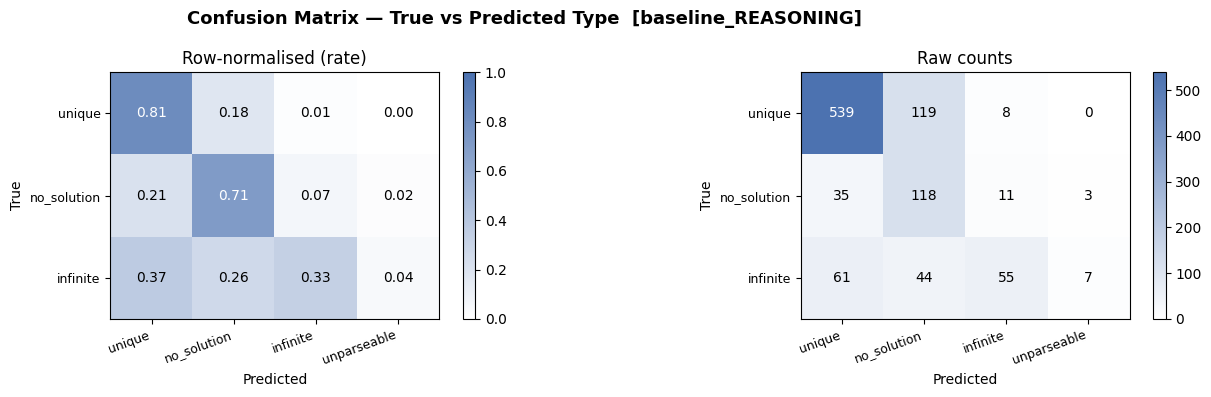

Saved: eval_confusion_matrix_baseline_REASONING.png


In [57]:
# ── Figure 2: Confusion matrix — true vs predicted type ─────────────────────────
from matplotlib.colors import LinearSegmentedColormap

_SOL_TYPES = ['unique', 'no_solution', 'infinite']
_ALL_PRED  = _SOL_TYPES + ['unparseable']

cm_raw = np.zeros((len(_SOL_TYPES), len(_ALL_PRED)), dtype=int)
for r in eval_results:
    ti = _SOL_TYPES.index(r['solution_type'])
    pj = (_ALL_PRED.index(r['pred_type'])
          if r['pred_type'] in _ALL_PRED else len(_ALL_PRED) - 1)
    cm_raw[ti, pj] += 1

cm_norm = cm_raw.astype(float) / cm_raw.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle(f'Confusion Matrix — True vs Predicted Type  [{EVAL_TAG}]',
             fontsize=13, fontweight='bold')

_cmap = LinearSegmentedColormap.from_list('wblue', ['#ffffff', '#4C72B0'])

for ax, data, title, fmt in [
    (axes[0], cm_norm, 'Row-normalised (rate)',  '.2f'),
    (axes[1], cm_raw,  'Raw counts',             'd'),
]:
    vmax = 1.0 if fmt == '.2f' else int(cm_raw.max())
    im   = ax.imshow(data, cmap=_cmap, vmin=0, vmax=vmax)
    ax.set_xticks(range(len(_ALL_PRED)))
    ax.set_xticklabels(_ALL_PRED, rotation=20, ha='right', fontsize=9)
    ax.set_yticks(range(len(_SOL_TYPES)))
    ax.set_yticklabels(_SOL_TYPES, fontsize=9)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(title)
    for i in range(len(_SOL_TYPES)):
        for j in range(len(_ALL_PRED)):
            val  = data[i, j]
            txt  = f'{val:{fmt}}' if fmt != 'd' else str(int(val))
            intensity = float(val) / vmax
            ax.text(j, i, txt, ha='center', va='center', fontsize=10,
                    color='white' if intensity > 0.55 else 'black')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig(f'eval_confusion_matrix_{EVAL_TAG}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: eval_confusion_matrix_{EVAL_TAG}.png')


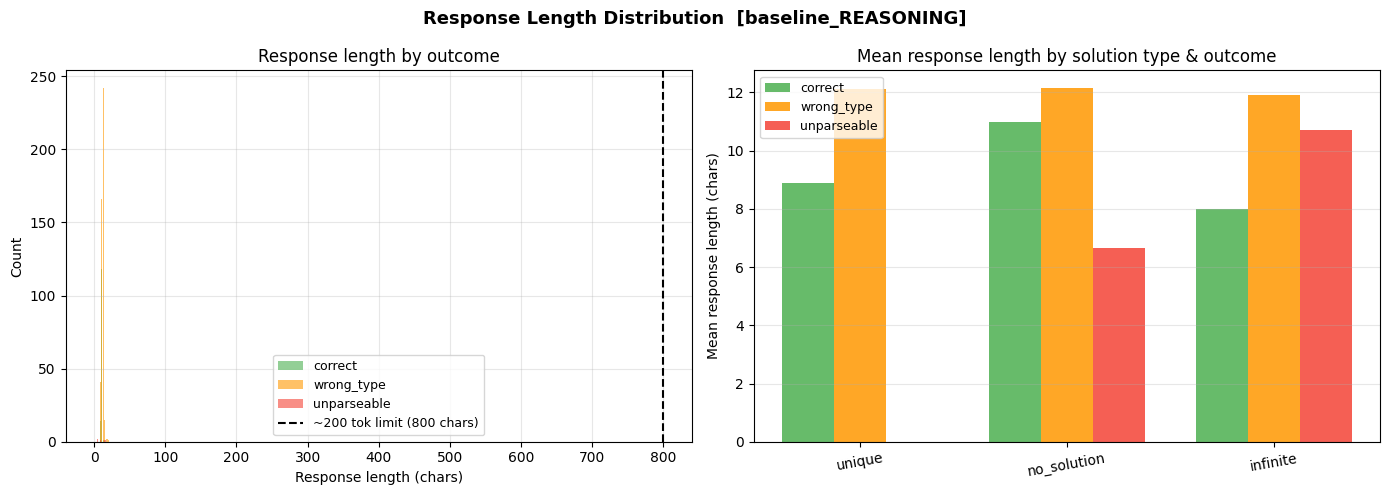

Saved: eval_response_length_baseline_REASONING.png


In [58]:
# ── Figure 3: Response length distribution ───────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

_out_labels = ['correct', 'wrong_type', 'unparseable']
_out_colors = {'correct': '#4CAF50', 'wrong_type': '#FF9800', 'unparseable': '#F44336'}

def _out(r):
    if r['pred_type'] == 'unparseable': return 'unparseable'
    if r['reward'] > 0:                 return 'correct'
    return 'wrong_type'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Response Length Distribution  [{EVAL_TAG}]', fontsize=13, fontweight='bold')

# Panel 1: overlaid histograms by outcome
ax = axes[0]
lengths = {lbl: [len(r['raw_output']) for r in eval_results if _out(r) == lbl]
           for lbl in _out_labels}
all_lengths = [l for v in lengths.values() for l in v]
bins = np.linspace(0, max(all_lengths) if all_lengths else 1, 40)
for lbl in _out_labels:
    ax.hist(lengths[lbl], bins=bins, alpha=0.6, label=lbl, color=_out_colors[lbl])

# Annotate approximate truncation cliff (~4 chars/token)
trunc_approx = MAX_TOKENS * 4
ax.axvline(trunc_approx, color='black', linestyle='--', linewidth=1.5,
           label=f'~{MAX_TOKENS} tok limit ({trunc_approx} chars)')
ax.set_xlabel('Response length (chars)')
ax.set_ylabel('Count')
ax.set_title('Response length by outcome')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Panel 2: mean response length by solution type & outcome
ax = axes[1]
_sol_types = ['unique', 'no_solution', 'infinite']
x = np.arange(len(_sol_types))
w = 0.25
for k, lbl in enumerate(_out_labels):
    means = []
    for st in _sol_types:
        lens = [len(r['raw_output']) for r in eval_results
                if r['solution_type'] == st and _out(r) == lbl]
        means.append(np.mean(lens) if lens else 0.0)
    ax.bar(x + (k - 1) * w, means, w, label=lbl, color=_out_colors[lbl], alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(_sol_types, rotation=10)
ax.set_ylabel('Mean response length (chars)')
ax.set_title('Mean response length by solution type & outcome')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'eval_response_length_{EVAL_TAG}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: eval_response_length_{EVAL_TAG}.png')


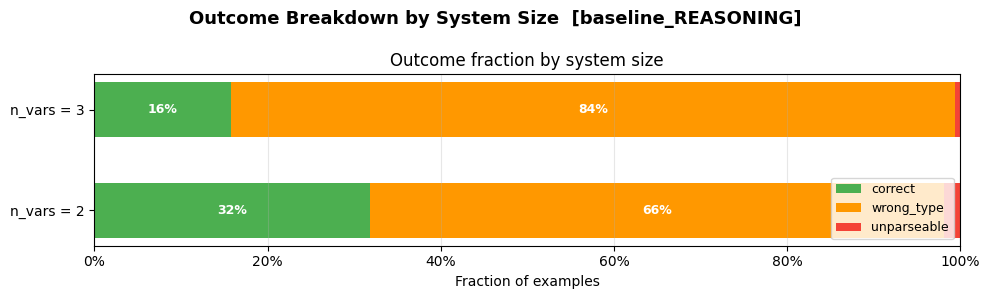

Saved: eval_n_vars_breakdown_baseline_REASONING.png


In [59]:
# ── Figure 4: Per-n_vars outcome breakdown ───────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

_out_labels = ['correct', 'wrong_type', 'unparseable']
_out_colors = {'correct': '#4CAF50', 'wrong_type': '#FF9800', 'unparseable': '#F44336'}

def _out(r):
    if r['pred_type'] == 'unparseable': return 'unparseable'
    if r['reward'] > 0:                 return 'correct'
    return 'wrong_type'

_nv_vals = sorted({r['n_vars'] for r in eval_results})

fig, ax = plt.subplots(figsize=(10, max(3, len(_nv_vals) * 1.2)))
fig.suptitle(f'Outcome Breakdown by System Size  [{EVAL_TAG}]', fontsize=13, fontweight='bold')

bar_h = 0.55
for i, nv in enumerate(_nv_vals):
    sub   = [r for r in eval_results if r['n_vars'] == nv]
    total = len(sub)
    left  = 0.0
    for lbl in _out_labels:
        count = sum(1 for r in sub if _out(r) == lbl)
        frac  = count / total if total else 0.0
        ax.barh(i, frac, bar_h, left=left, color=_out_colors[lbl],
                label=lbl if i == 0 else '')
        if frac > 0.04:
            ax.text(left + frac / 2, i, f'{frac:.0%}',
                    ha='center', va='center', fontsize=9,
                    color='white', fontweight='bold')
        left += frac

ax.set_yticks(range(len(_nv_vals)))
ax.set_yticklabels([f'n_vars = {nv}' for nv in _nv_vals])
ax.set_xlabel('Fraction of examples')
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title('Outcome fraction by system size')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(f'eval_n_vars_breakdown_{EVAL_TAG}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: eval_n_vars_breakdown_{EVAL_TAG}.png')


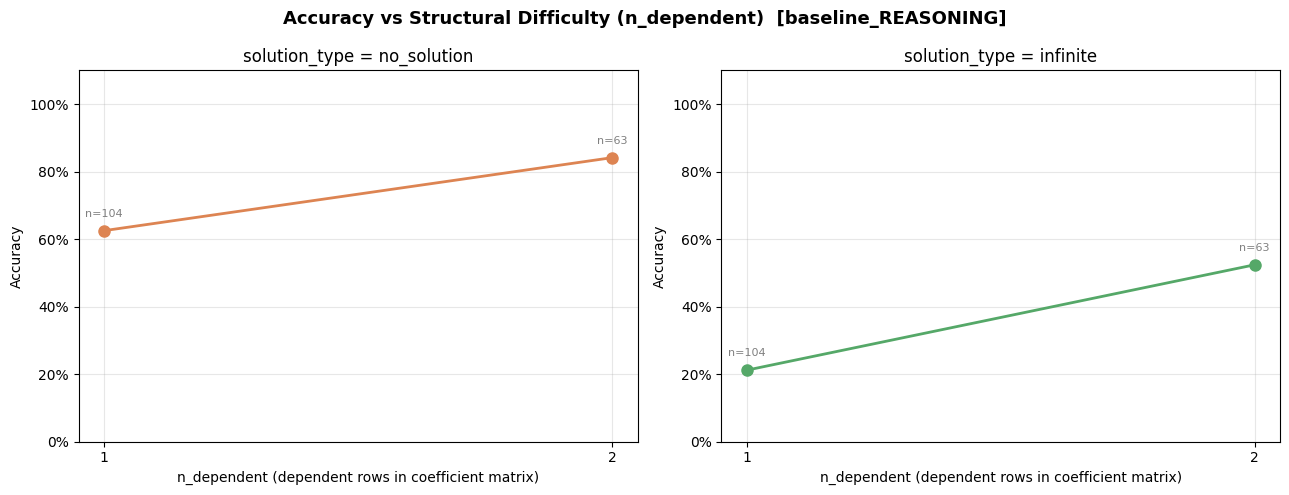

Saved: eval_n_dependent_baseline_REASONING.png


In [60]:
# ── Figure 5: Accuracy vs n_dependent (structural difficulty) ────────────────
# n_dependent = number of linearly dependent rows in the coefficient matrix.
# Relevant for 'infinite' and 'no_solution' types (unique always has n_dependent=0).
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

_dep_types  = ['no_solution', 'infinite']
_dep_colors = {'no_solution': '#DD8452', 'infinite': '#55A868'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'Accuracy vs Structural Difficulty (n_dependent)  [{EVAL_TAG}]',
             fontsize=13, fontweight='bold')

for ax, dep_type in zip(axes, _dep_types):
    sub      = [r for r in eval_results if r['solution_type'] == dep_type]
    dep_vals = sorted({r['n_dependent'] for r in sub})
    accs, ns = [], []
    for dv in dep_vals:
        bucket = [r for r in sub if r['n_dependent'] == dv]
        accs.append(sum(1 for r in bucket if r['reward'] > 0) / len(bucket) if bucket else 0.0)
        ns.append(len(bucket))

    ax.plot(dep_vals, accs, 'o-', color=_dep_colors[dep_type], linewidth=2, markersize=8)
    for x, y, n in zip(dep_vals, accs, ns):
        ax.annotate(f'n={n}', (x, y), textcoords='offset points',
                    xytext=(0, 10), ha='center', fontsize=8, color='gray')

    ax.set_xlabel('n_dependent (dependent rows in coefficient matrix)')
    ax.set_ylabel('Accuracy')
    ax.set_title(f'solution_type = {dep_type}')
    ax.set_ylim(0, 1.1)
    if dep_vals:
        ax.set_xticks(dep_vals)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'eval_n_dependent_{EVAL_TAG}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: eval_n_dependent_{EVAL_TAG}.png')


#### 2.5.6 — Save Results


In [62]:
# ── Mount Google Drive ────────────────────────────────────────────────────────
from google.colab import drive
import os

drive.mount('/content/drive')

# Path to the shared Drive results folder (kept for reference / manual browsing).
# The save cell (2.5.6) uploads via the Drive API and does NOT need this to be
# the working directory — do NOT os.chdir() here, as it moves writes onto the
# FUSE filesystem which does not support append mode.
RESULTS_DIR = '/content/drive/.shortcut-targets-by-id/1P1qRVvARJ_KMy9tOHfqdwt3ooZ_5zRV9'

if not os.path.isdir(RESULTS_DIR):
    print('Shortcut path not found. Available shared drives:')
    for d in os.listdir('/content/drive/Shareddrives'):
        print(f'  /content/drive/Shareddrives/{d}')
    raise RuntimeError('Update RESULTS_DIR above with the correct path.')

print(f'Drive mounted. Results folder: {RESULTS_DIR}')
print(f'Working directory: {os.getcwd()}  (unchanged — local writes stay here)')

Mounted at /content/drive
Drive mounted. Results folder: /content/drive/.shortcut-targets-by-id/1P1qRVvARJ_KMy9tOHfqdwt3ooZ_5zRV9
Working directory: /content  (unchanged — local writes stay here)


In [63]:
import json, datetime, shutil
from collections import Counter

# ── Optionally fetch Azure training metadata (fine-tuned models only) ─────────
training_metadata = None
if IS_FINETUNED:
    print(f'Fetching training metadata for: {EVAL_DEPLOYMENT_NAME} ...')
    training_metadata = fetch_training_metadata(openai_client, EVAL_DEPLOYMENT_NAME)
    if training_metadata:
        print(f'  Found job: {training_metadata["job_id"]}  method={training_metadata["method"]}')
    else:
        print('  No matching fine-tuning job found — check EVAL_DEPLOYMENT_NAME.')

# ── Build eval set breakdown ──────────────────────────────────────────────────
_nvars_vals = sorted({r['n_vars'] for r in eval_results})
_sol_types  = ['unique', 'no_solution', 'infinite']

_by_type_x_nvars = {
    st: {str(nv): sum(1 for r in eval_results
                      if r['solution_type'] == st and r['n_vars'] == nv)
         for nv in _nvars_vals}
    for st in _sol_types
}

_unparse_cats = Counter(
    categorise_unparseable(r['raw_output'], r['n_vars'])
    for r in eval_results if r['pred_type'] == 'unparseable'
)

# ── Timestamp for this save (run_id was set in the eval config cell) ──────────
_ts = datetime.datetime.now(datetime.timezone.utc).isoformat(timespec='seconds')

# ── Assemble rich summary ─────────────────────────────────────────────────────
rich_summary = {
    'run_id':          _run_id,
    'timestamp':       _ts,
    'deployment_name': EVAL_DEPLOYMENT_NAME,
    'eval_tag':        EVAL_TAG,
    'notes':           EVAL_NOTES,
    'eval_config': {
        'n_examples':    len(eval_results),
        'max_tokens':    MAX_TOKENS,
        'temperature':   TEMPERATURE,
        'eval_file':     EVAL_JSONL,
        'max_workers':   MAX_WORKERS,
        'system_prompt': SYSTEM_PROMPT,
    },
    'eval_set_breakdown': {
        'total':             len(eval_results),
        'by_type':           {st: sum(1 for r in eval_results if r['solution_type'] == st)
                              for st in _sol_types},
        'by_n_vars':         {str(nv): sum(1 for r in eval_results if r['n_vars'] == nv)
                              for nv in _nvars_vals},
        'by_type_x_n_vars':  _by_type_x_nvars,
    },
    'results_summary': {
        'overall_accuracy': eval_summary['accuracy'],
        'api_errors':       eval_summary['errors'],
        'by_type': {
            st: {
                'n':        eval_summary['by_type'][st]['n'],
                'correct':  eval_summary['by_type'][st]['correct'],
                'accuracy': (eval_summary['by_type'][st]['correct'] /
                             eval_summary['by_type'][st]['n'])
                            if eval_summary['by_type'][st]['n'] else 0.0,
            }
            for st in _sol_types
        },
        'by_n_vars': {
            str(nv): {
                'n':        eval_summary['by_n_vars'][nv]['n'],
                'correct':  eval_summary['by_n_vars'][nv]['correct'],
                'accuracy': (eval_summary['by_n_vars'][nv]['correct'] /
                             eval_summary['by_n_vars'][nv]['n'])
                            if eval_summary['by_n_vars'][nv]['n'] else 0.0,
            }
            for nv in eval_summary['by_n_vars']
        },
        'unparseable_breakdown': dict(_unparse_cats),
    },
    'model_training_metadata': training_metadata,
    'results_detail': [
        {
            'idx':           i,
            'solution_type': eval_results[i]['solution_type'],
            'n_vars':        eval_results[i]['n_vars'],
            'input':         held_out_eval[i]['messages'][-1]['content'],
            'expected':      eval_results[i]['expected'],
            'observed':      eval_results[i]['raw_output'],
            'reward':        eval_results[i]['reward'],
        }
        for i in range(len(eval_results))
    ],
}

# ── Save to Google Drive ──────────────────────────────────────────────────────
import io
from googleapiclient.discovery import build
from googleapiclient.http import MediaIoBaseUpload
from google.colab import auth

RESULTS_FOLDER_ID = '1P1qRVvARJ_KMy9tOHfqdwt3ooZ_5zRV9'
_summary_path     = f'eval_summary_{_run_id}.json'

auth.authenticate_user()
_drive = build('drive', 'v3', cache_discovery=False)

_media = MediaIoBaseUpload(
    io.BytesIO(json.dumps(rich_summary, indent=2).encode()),
    mimetype='application/json'
)

# Update if already exists, create otherwise (avoids duplicates on re-run)
_existing = _drive.files().list(
    q=f"name='{_summary_path}' and '{RESULTS_FOLDER_ID}' in parents and trashed=false",
    supportsAllDrives=True, includeItemsFromAllDrives=True,
    fields='files(id)'
).execute().get('files', [])

if _existing:
    _drive.files().update(
        fileId=_existing[0]['id'], media_body=_media, supportsAllDrives=True
    ).execute()
    print(f'Updated: {_summary_path}')
else:
    _drive.files().create(
        body={'name': _summary_path, 'parents': [RESULTS_FOLDER_ID]},
        media_body=_media, supportsAllDrives=True
    ).execute()
    print(f'Created: {_summary_path}')

print(f'  run_id    : {_run_id}')
print(f'  accuracy  : {rich_summary["results_summary"]["overall_accuracy"]:.3f}')
print(f'  n_examples: {len(eval_results)}')
print(f'  detail    : {len(rich_summary["results_detail"])} per-example records included')
if training_metadata:
    print(f'  job_id    : {training_metadata["job_id"]}')
    print(f'  method    : {training_metadata["method"]}')
print(f'Raw results : eval_results_{_run_id}.jsonl')


Fetching training metadata for: gpt-4.1-nano ...
  No matching fine-tuning job found — check EVAL_DEPLOYMENT_NAME.


Created: eval_summary_20260504_230727_baseline_REASONING.json
  run_id    : 20260504_230727_baseline_REASONING
  accuracy  : 0.210
  n_examples: 1000
  detail    : 1000 per-example records included
Raw results : eval_results_20260504_230727_baseline_REASONING.jsonl


## 3 — Upload Training Files

Upload the training and validation JSONL files to Microsoft Foundry.
Each file is assigned a unique ID that will be referenced when creating
the fine-tuning job.

> **Prerequisites:**
> - `training.jsonl` and `validation.jsonl` must exist on disk — generated by
>   **Section 0.5**.  Run Section 0 once per machine; the files persist across
>   runtimes.
> - `openai_client` must be in scope — run **Section 2.3**.


In [ ]:
# These paths are set in Section 0.1 and match the files written by Section 0.5.
training_file_path   = TRAIN_JSONL    # 'training.jsonl'
validation_file_path = VAL_JSONL      # 'validation.jsonl'

In [ ]:
print('Uploading training file ...')
with open(training_file_path, 'rb') as f:
    train_file = openai_client.files.create(file=f, purpose='fine-tune')

print('Uploading validation file ...')
with open(validation_file_path, 'rb') as f:
    validation_file = openai_client.files.create(file=f, purpose='fine-tune')

train_file_id = train_file.id
val_file_id   = validation_file.id

print(f'Training file ID:   {train_file_id}')
print(f'Validation file ID: {val_file_id}')

Uploading training file ...
Uploading validation file ...
Training file ID:   file-d3eaf23581bf498bb64f6aa5923beaed
Validation file ID: file-6016183103ec4104b0f7070b6056434b


In [ ]:
print('Waiting for files to be processed ...')
openai_client.files.wait_for_processing(train_file_id)
openai_client.files.wait_for_processing(val_file_id)
print('Files ready!')

Waiting for files to be processed ...
Files ready!


## 4 — Create a Fine-Tuning Job

Create a fine-tuning job with your uploaded datasets. Configure the following
hyperparameters to control the training process:

**Hyperparameters:**
1. **n_epochs (1):** Number of complete passes through the training dataset.
   More epochs can improve performance but risk overfitting.
2. **batch_size (1):** Number of training examples processed together.
   Larger batches are more stable but require more memory.
3. **learning_rate_multiplier (1.0):** Scales the default learning rate.
   Values < 1.0 make training more conservative; values > 1.0 speed up
   learning but may cause instability. Typical range: 0.1–2.0.

**Note:** Adjust these based on your dataset size and quality.

> **Prerequisites:** `train_file_id` and `val_file_id` from **Section 3**.
> For **Section 4.3 (RFT)** only: `RFT_GRADER_STUB` from **Section 0.7** must
> also be in scope — run Section 0.7 or all of Section 0 first.
>
> **Note on job variable naming:** All three subsections (SFT, DPO, RFT) assign
> their job to `fine_tune_job`.  Run only the subsection corresponding to your
> chosen training method; the job ID printed there is what Section 5 monitors.


### 4.1 — Supervised Fine-Tuning


In [ ]:
model_name = 'gpt-4.1-nano-2025-04-14'
print(f'Creating supervised fine-tuning job for {model_name}')

fine_tune_job = openai_client.fine_tuning.jobs.create(
    model           = model_name,
    training_file   = train_file_id,
    validation_file = val_file_id,
    method = {
        'type': 'supervised',
        'supervised': {
            'hyperparameters': {
                'n_epochs':               1,
                'batch_size':             2,
                'learning_rate_multiplier': 0.3,
            }
        },
    },
    extra_body = {'trainingType': 'GlobalStandard'},
    suffix     = 'linear-eq-sft',
)

print(f'Fine-tuning job created!')
print(f'Job ID: {fine_tune_job.id}')
print(f'Status: {fine_tune_job.status}')
print(f'Model:  {fine_tune_job.model}')

Creating supervised fine-tuning job for gpt-4.1-nano-2025-04-14
Fine-tuning job created!
Job ID: ftjob-8def347662494c868f2c589c70719fff
Status: pending
Model:  gpt-4.1-nano-2025-04-14


### 4.2 — Direct Preference Optimization


In [ ]:
print(f'Creating DPO fine-tuning job for {model_name}')

fine_tune_job = openai_client.fine_tuning.jobs.create(
    training_file   = train_file_id,
    validation_file = val_file_id,
    model           = model_name,
    method = {
        'type': 'dpo',
        'dpo': {
            'hyperparameters': {
                'n_epochs':               1,
                'batch_size':             1,
                'learning_rate_multiplier': 1.0,
            }
        },
    },
    extra_body = {'trainingType': 'GlobalStandard'},
)

print(f'Job ID: {fine_tune_job.id}')
print(f'Status: {fine_tune_job.status}')


## 5 — Monitor Training Progress

Track the status of your fine-tuning job.  Training duration varies based
on dataset size, model, and hyperparameters — typically ranging from minutes
to several hours.

> **Prerequisites:** `fine_tune_job` must be in scope — set by whichever
> Section 4 subsection you ran (SFT / DPO / RFT).
>
> **Fresh-runtime re-attach:** If `fine_tune_job` is no longer in scope, use the
> *"Retrieve specific job"* cell below — paste your job ID (printed in Section 4)
> into the `'YOUR_JOB_ID_HERE'` placeholder and run that cell first.


In [ ]:
for job in openai_client.fine_tuning.jobs.list().data:
       print(job.id, job.status, job.created_at)

ftjob-8def347662494c868f2c589c70719fff succeeded 1777494971
ftjob-bd84686301104c5297c4787bdbaf6186 succeeded 1777492309
ftjob-2a87289099f74ed7879c494b3cb4457b succeeded 1777480954
ftjob-27d3234ba5b1490bad814001ff93372c running 1777389611
ftjob-bf038f2312c544959ed9eff0cd497e18 succeeded 1777389442
ftjob-ec8c17d3e82d41aab763cab4c6435258 succeeded 1777349340
ftjob-1ab1da41679f4d18a37d385eecd073a9 succeeded 1777340188
ftjob-3da1b1a29c084d5c998c6029fb7fccd8 succeeded 1777340159
ftjob-784014e89c97476c9dfa6e4124574591 succeeded 1777007203
ftjob-560c4b5d4bf14dbb840fd1749dae3295 succeeded 1776889585


In [ ]:
# TODO: Replace 'YOUR_JOB_ID_HERE' with the job ID printed by Section 4
# (e.g. 'ftjob-784014e89c97476c9dfa6e4124574591').
# Use this cell to re-attach to a job in a fresh runtime or to check a
# specific job by ID without re-running Section 4.
fine_tune_job = openai_client.fine_tuning.jobs.retrieve('ftjob-8def347662494c868f2c589c70719fff')
print(f'recovered: {fine_tune_job.id}, status: {fine_tune_job.status}')


recovered: ftjob-8def347662494c868f2c589c70719fff, status: succeeded


In [ ]:
# View recent events — .data fetches only the first page (limit=10) without
# exhausting the full paginator, which can block indefinitely.
events = openai_client.fine_tuning.jobs.list_events(fine_tune_job.id, limit=10).data
for event in events:
    print(event.message)


Training tokens billed: 2600000
Model Evaluation Passed.
Completed results file: file-cb9f5ec8bf484708a3358900b6bc1950
Job succeeded.
Step 5000: training loss=0.007733858190476894
Step 4990: training loss=0.009552408941090107
Step 4980: training loss=0.04720539599657059
Step 4970: training loss=0.07412665337324142
Step 4960: training loss=0.04821506142616272
Step 4950: training loss=0.0006175223388709128


In [ ]:
job_status = openai_client.fine_tuning.jobs.retrieve(fine_tune_job.id)
print(f'Status: {job_status.status}')

NameError: name 'openai_client' is not defined

After the fine-tuning job succeeds, retrieve the fine-tuned model ID.
This ID is required to make inference calls with your customised model.

In [ ]:
completed_job = openai_client.fine_tuning.jobs.retrieve(fine_tune_job.id)

if completed_job.status == 'succeeded':
    fine_tuned_model_id = completed_job.fine_tuned_model
    print(f'Fine-tuned Model ID: {fine_tuned_model_id}')
else:
    print(f'Status: {completed_job.status}')

Fine-tuned Model ID: gpt-4.1-nano-2025-04-14.ft-8def347662494c868f2c589c70719fff-linear-eq-sft


In [ ]:
completed_job.result_files

['file-cb9f5ec8bf484708a3358900b6bc1950']

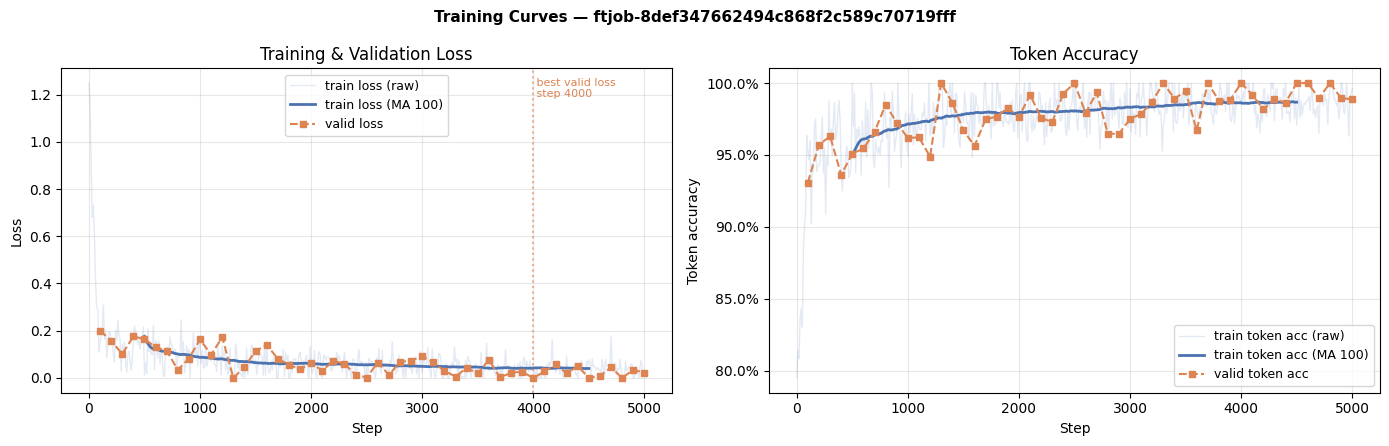

Saved: training_curves.png  (501 metric steps recorded)
Lowest validation loss : 0.0000  at step 4000
  → To deploy that checkpoint, re-run fine-tuning with n_epochs capped at step 4000


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# ── 1. Paginate through ALL events and collect those with step metrics ────────
_all_metrics = []
_page = openai_client.fine_tuning.jobs.list_events(fine_tune_job.id, limit=100000)
while True:
    for _e in _page.data:
        _d = getattr(_e, 'data', None)
        if isinstance(_d, dict) and 'train_loss' in _d:
            _all_metrics.append(_d)
    if not getattr(_page, 'has_more', False):
        break
    _page = openai_client.fine_tuning.jobs.list_events(
        fine_tune_job.id, limit=100, after=_page.data[-1].id
    )

def _moving_average(values, window=100):
    """Compute a centered moving average, handling None values."""
    vals = np.array([v if v is not None else np.nan for v in values], dtype=float)
    kernel = np.ones(window) / window
    # Use 'same' convolution then mask edges where the window is incomplete
    smoothed = np.convolve(vals, kernel, mode='same')
    half = window // 2
    smoothed[:half] = np.nan
    smoothed[len(smoothed) - half:] = np.nan
    return smoothed

if not _all_metrics:
    print("No metric events found yet. Check that the job status is 'running' or 'succeeded'.")
else:
    _all_metrics.sort(key=lambda d: d.get('step', 0))
    _steps      = [d['step']                          for d in _all_metrics]
    _train_loss = [d.get('train_loss')                for d in _all_metrics]
    _valid_loss = [d.get('valid_loss')                for d in _all_metrics]
    _train_acc  = [d.get('train_mean_token_accuracy') for d in _all_metrics]
    _valid_acc  = [d.get('valid_mean_token_accuracy') for d in _all_metrics]

    _has_valid = any(v is not None for v in _valid_loss)
    _has_acc   = any(v is not None for v in _train_acc)

    # Precompute smoothed series
    _MA_WINDOW = 100
    _train_loss_smooth = _moving_average(_train_loss, _MA_WINDOW)
    _train_acc_smooth  = _moving_average(_train_acc,  _MA_WINDOW) if _has_acc else None

    _ncols = 1 + int(_has_acc)
    _fig, _axes = plt.subplots(1, _ncols, figsize=(7 * _ncols, 4.5))
    if _ncols == 1:
        _axes = [_axes]
    _fig.suptitle(f'Training Curves — {fine_tune_job.id}', fontsize=11, fontweight='bold')

    # ── Panel 1: Loss ─────────────────────────────────────────────────────────
    _ax = _axes[0]
    # Raw train loss — significantly faded
    _ax.plot(_steps, _train_loss, '-', color='#4C72B0',
             label='train loss (raw)', linewidth=1.0, markersize=2, alpha=0.15)
    # Smoothed train loss — full opacity, slightly thicker
    _ax.plot(_steps, _train_loss_smooth, '-', color='#4C72B0',
             label=f'train loss (MA {_MA_WINDOW})', linewidth=2.0)

    if _has_valid:
        _vx = [s for s, v in zip(_steps, _valid_loss) if v is not None]
        _vy = [v for v in _valid_loss if v is not None]
        _ax.plot(_vx, _vy, 's--', color='#DD8452',
                 label='valid loss', linewidth=1.5, markersize=4)
        _best_step = _vx[_vy.index(min(_vy))]
        _ax.axvline(_best_step, color='#DD8452', linestyle=':', alpha=0.6)
        _ax.text(_best_step, max(_ax.get_ylim()) * 0.97,
                 f' best valid loss\n step {_best_step}',
                 color='#DD8452', fontsize=8, va='top')
    _ax.set_xlabel('Step'); _ax.set_ylabel('Loss')
    _ax.set_title('Training & Validation Loss')
    _ax.legend(fontsize=9); _ax.grid(True, alpha=0.3)

    # ── Panel 2: Token accuracy (if reported) ─────────────────────────────────
    if _has_acc:
        _ax2 = _axes[1]
        _ta_x = [s for s, v in zip(_steps, _train_acc) if v is not None]
        _ta_y = [v for v in _train_acc if v is not None]
        # Raw train acc — significantly faded
        _ax2.plot(_ta_x, _ta_y, '-', color='#4C72B0',
                  label='train token acc (raw)', linewidth=1.0, markersize=2, alpha=0.15)
        # Smoothed train acc — full opacity
        _ta_smooth_x = [s for s, v in zip(_steps, _train_acc_smooth) if not np.isnan(v)]
        _ta_smooth_y = [v for v in _train_acc_smooth if not np.isnan(v)]
        _ax2.plot(_ta_smooth_x, _ta_smooth_y, '-', color='#4C72B0',
                  label=f'train token acc (MA {_MA_WINDOW})', linewidth=2.0)

        if any(v is not None for v in _valid_acc):
            _va_x = [s for s, v in zip(_steps, _valid_acc) if v is not None]
            _va_y = [v for v in _valid_acc if v is not None]
            _ax2.plot(_va_x, _va_y, 's--', color='#DD8452',
                      label='valid token acc', linewidth=1.5, markersize=4)
        _ax2.set_xlabel('Step'); _ax2.set_ylabel('Token accuracy')
        _ax2.set_title('Token Accuracy')
        _ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
        _ax2.legend(fontsize=9); _ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: training_curves.png  ({len(_all_metrics)} metric steps recorded)')
    if _has_valid:
        _best_val = min(v for v in _valid_loss if v is not None)
        print(f'Lowest validation loss : {_best_val:.4f}  at step {_best_step}')
        print(f'  → To deploy that checkpoint, re-run fine-tuning with n_epochs capped at step {_best_step}')

## 6 — Deploy the Fine-Tuned Model

Deploy the fine-tuned model to Azure OpenAI as a deployment endpoint.
This step is required before making inference calls.

> **Prerequisites:** `fine_tuned_model_id` from **Section 5** and Azure
> management credentials (`CREDENTIAL`, `SUBSCRIPTION_ID`, `RESOURCE_GROUP`)
> from **Section 2.2–2.3**.


In [ ]:
deployment_name = '1-nano-2025-04-14-linear-eq-sft'

In [ ]:
with CognitiveServicesManagementClient(credential=CREDENTIAL,
                                       subscription_id=SUBSCRIPTION_ID) as cogsvc_client:
    deployment_model      = DeploymentModel(format='OpenAI', name=fine_tuned_model_id, version='1')
    deployment_properties = DeploymentProperties(model=deployment_model)
    deployment_sku        = Sku(name='GlobalStandard', capacity=50)
    deployment_config     = Deployment(properties=deployment_properties, sku=deployment_sku)

    print(f'Deploying fine-tuned model: {fine_tuned_model_id}')
    deployment = cogsvc_client.deployments.begin_create_or_update(
        resource_group_name = 'CIS-5270',
        account_name        = RESOURCE_GROUP,
        deployment_name     = deployment_name,
        deployment          = deployment_config,
    )

    print('Waiting for deployment to complete ...')
    deployment.result()

print(f'Model deployment completed: {deployment_name}')

## 7 — Test Fine-Tuned Model

Validate your fine-tuned model by running a few test inferences against
held-out examples from `eval.jsonl`.

> **Prerequisites:** `deployment_name` from **Section 6**, `openai_client` from
> **Section 2.3**, and `held_out_eval` in scope (run **Section 0.5**, or reload
> via **Section 2.5.2** with Sections 0.1 + 0.7–0.8 first).
>
> **To run the full evaluation** on the fine-tuned model, update
> `EVAL_DEPLOYMENT_NAME` and `EVAL_TAG` in the Section 2.5 config cell and
> re-run Section 2.5 in its entirety.


In [ ]:
# TODO: Plug in actual deployment name
deployment_name = '1-nano-2025-04-14-linear-eq-sft'

In [ ]:
# Sample a few held-out eval examples and query the deployed fine-tuned model
import random as _random

test_examples = _random.sample(held_out_eval, min(5, len(held_out_eval)))

for ex in test_examples:
    response = openai_client.chat.completions.create(
        model       = deployment_name,
        messages    = ex['messages'],
        max_tokens  = REASONING_MAX_TOKENS if INCLUDE_REASONING else MAX_TOKENS,
        temperature = 0,
    )
    raw_output = response.choices[0].message.content
    pred_type, pred_vals = parse_model_output(raw_output, ex['n_vars'])
    reward = compute_reward(pred_type, pred_vals, ex['solution_type'],
                            ex['A'], ex['b'], ex['n_vars'])

    print(f'--- n={ex["n_vars"]}  true={ex["solution_type"]}  '
          f'pred={pred_type}  reward={reward:+.1f} ---')
    print(ex['messages'][1]['content'])
    print(f'Model output : {raw_output}')
    print(f'Expected     : {ex["answer"]}')
    print()


--- n=5  true=no_solution  pred=unparseable  reward=-1.0 ---
-3x - 3y - 2z + 3w + 4u = 9
-3x - y + 2z + w + 4u = 23
5x - 2y - 4z - w - 2u = -29
-2x + 6y + 6z + w - 4u = 26
-5x - 2y - 4z + 5w + 2u = 4
Model output : NONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONONON

### 7.5 — Full Evaluation

To run the full 6 000-example evaluation on the fine-tuned model:

1. Update `EVAL_DEPLOYMENT_NAME = deployment_name` in the Section 2.5 config cell.
2. Update `EVAL_TAG` (e.g. `'sft'`) and set `IS_FINETUNED = True`.
3. Re-run all cells in **Section 2.5**.

Results will be saved to `eval_results_{EVAL_TAG}.jsonl` and
`eval_summary_{EVAL_TAG}.json` with full training metadata from Azure.


## 8. Remove Deployment

**Warning:** Do not leave the fine-tuned model deployment running after testing.
Active Azure OpenAI deployments incur significant ongoing cost.  Always delete
the deployment as soon as required validation / testing is complete.  You can
redeploy the same fine-tuned model ID later whenever you need more inference tests.

In [ ]:
with CognitiveServicesManagementClient(credential=CREDENTIAL,
                                       subscription_id=SUBSCRIPTION_ID) as cogsvc_client:
    print(f'Deleting deployment: {deployment_name}')
    poller = cogsvc_client.deployments.begin_delete(
        resource_group_name = 'CIS-5270',
        account_name        = RESOURCE_GROUP,
        deployment_name     = deployment_name,
    )
    poller.result()

print(f'Deployment deleted: {deployment_name}')

## Congratulations!

You've successfully run the full pipeline:
- Generated synthetic linear-systems data (Section 0)
- Fine-tuned a model on Azure Foundry (Section 4)
- Evaluated the fine-tuned model (Section 7)
- Cleaned up the deployment (Section 8)